# AOD Comparison: Satellite vs AERONET Ground Truth — Vietnam Stations (v3)

## Sources
| Source | Type | Level | AOD wavelength | Temporal |
|--------|------|-------|---------------|----------|
| **AERONET** | Ground | L1.5 | 500nm → interpolated 550nm | Multi-daily (~5min) |
| **Himawari-8/9** | Geostationary | L2 (10-min) | 550nm (`AOT_mean`) | 10-min intervals |
| **Himawari-8/9** | Geostationary | L3 (hourly) | 550nm (`AOT_Merged_mean`) | Hourly |
| **MODIS** MCD19A2 | Polar orbit | MAIAC | 550nm (`Optical_Depth_055`) | ~1-2 overpasses/day |
| **VIIRS** NOAA-20 | Polar orbit | L2 | ~550nm (`aod`) | ~1-2 overpasses/day |

## AERONET Stations
| Station | Lat | Lon | City |
|---------|-----|-----|------|
| **NGHIA_DO** | 21.048°N | 105.800°E | Hanoi |
| **Bac_Lieu** | 9.30°N | 105.70°E | Bac Lieu |

## Comparison Groups
- **L2 group**: Himawari L2 + MODIS + VIIRS ↔ AERONET (time-matched ±30 min)
- **L3 group**: Himawari L3 ↔ AERONET (daily mean)

## Changes from v2
- Added VIIRS NOAA-20 L2 AOD (nearest_pixel preferred, radius_avg fallback)
- Distance filtering (< 25 km) and QA filtering applied
- Bonus: nearest_pixel vs radius_avg sensitivity analysis

In [70]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": 13, "font.size": 11, "figure.dpi": 120})

# Data paths
AERONET_DIR   = "/home/slow_data/Air_Quality/AERONET"
HIMAWARI_L2   = "/home/slow_data/Air_Quality/Himawari/sites_aod_v3/L2"
HIMAWARI_L3   = "/home/slow_data/Air_Quality/Himawari/sites_aod_v3/L3"
MODIS_DIR     = "/home/slow_data/Air_Quality/MODIS_MCD19A2/sites_aod_v3"
VIIRS_DIR     = "/home/slow_data/Air_Quality/VIIRS/output/L2_NOAA20"

# Stations with AERONET ground truth
STATIONS = {
    "NGHIA_DO": {"lat": 21.048, "lon": 105.800, "city": "Hanoi"},
    "Bac_Lieu":  {"lat": 9.30,  "lon": 105.70,  "city": "Bac Lieu"},
}

COLORS = {
    "AERONET":      "#2196F3",
    "Himawari_L2":  "#FFD54F",
    "Himawari_L3":  "#FF9800",
    "MODIS":        "#9C27B0",
    "VIIRS":        "#4CAF50",
    "VIIRS_nearest":"#4CAF50",
    "VIIRS_radius": "#00897B",
}

TIME_WINDOW_MIN = 30   # ±30 min for L2 time matching (Ichoku et al. 2002)
VIIRS_DIST_KM   = 25   # max distance for VIIRS nearest_pixel

print("Setup complete.")

Setup complete.


## 1. Load Data

In [71]:
# ── 1.1 AERONET (ground truth) ──
# Level 10 = all points (highest temporal resolution)
# Interpolate AOD_500nm → AOD_550nm using Angstrom Exponent:
#   AOD_550 = AOD_500 * (550/500)^(-AE_{440-675})

AERONET_L10_DIR = os.path.join(AERONET_DIR, "10")

def load_aeronet(site: str) -> pd.DataFrame:
    fp = os.path.join(AERONET_L10_DIR, f"{site}.csv")
    if not os.path.exists(fp):
        import glob
        pattern = f"{AERONET_DIR}/{site}/aeronet_{site}_L15_*.csv"
        files = glob.glob(pattern)
        fp = files[0] if files else None
    if not fp or not os.path.exists(fp):
        print(f"  No AERONET file found for {site}")
        return pd.DataFrame()
    df = pd.read_csv(fp)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["AOD_500"] = pd.to_numeric(df["AOD_500nm"], errors="coerce")
    ae_col = "440-675_Angstrom_Exponent"
    df["AE"] = pd.to_numeric(df[ae_col], errors="coerce")
    df["AOD_550"] = df["AOD_500"] * (550.0 / 500.0) ** (-df["AE"])
    df = df.dropna(subset=["AOD_550", "datetime"]).reset_index(drop=True)
    df["date"] = df["datetime"].dt.date
    df["station"] = site
    return df

aeronet = {site: load_aeronet(site) for site in STATIONS}

for site, df in aeronet.items():
    if df.empty:
        print(f"AERONET {site}: NO DATA")
    else:
        print(f"AERONET {site}: {len(df):,} records  "
              f"{df['datetime'].min().date()} → {df['datetime'].max().date()}  "
              f"AOD_550 mean={df['AOD_550'].mean():.3f}")

AERONET NGHIA_DO: 13,172 records  2022-02-23 → 2026-04-23  AOD_550 mean=0.699
AERONET Bac_Lieu: 15,690 records  2022-04-21 → 2025-08-22  AOD_550 mean=0.212


In [72]:
# ── 1.2 Himawari L2 (10-min) and L3 (hourly) ──
# L2:  key column = AOT_mean  (AOT_inner_mean as fallback)
# L3:  key column = AOT_Merged_mean  (AOT_L2_Mean as fallback)

def load_himawari_l2(site: str) -> pd.DataFrame:
    fp = os.path.join(HIMAWARI_L2, f"{site}.csv")
    if not os.path.exists(fp):
        return pd.DataFrame()
    df = pd.read_csv(fp, parse_dates=["timestamp"])
    df.rename(columns={"timestamp": "datetime"}, inplace=True)
    df["aod"] = pd.to_numeric(df["AOT_mean"], errors="coerce")
    # Basic quality: positive AOD, reasonable upper bound
    df.loc[df["aod"] <= 0, "aod"] = np.nan
    df.loc[df["aod"] > 5,  "aod"] = np.nan
    df["station"] = site
    df["date"] = df["datetime"].dt.date
    return df.dropna(subset=["datetime"]).reset_index(drop=True)


def load_himawari_l3(site: str) -> pd.DataFrame:
    fp = os.path.join(HIMAWARI_L3, f"{site}.csv")
    if not os.path.exists(fp):
        return pd.DataFrame()
    df = pd.read_csv(fp, parse_dates=["timestamp"])
    df.rename(columns={"timestamp": "datetime"}, inplace=True)
    df["AOT_Merged_mean"] = pd.to_numeric(df["AOT_Merged_mean"], errors="coerce")
    df["AOT_L2_Mean"]     = pd.to_numeric(df["AOT_L2_Mean"],     errors="coerce")
    # Prefer AOT_Merged_mean; fall back to AOT_L2_Mean
    df["aod"] = df["AOT_Merged_mean"].where(df["AOT_Merged_mean"] > 0)
    df.loc[df["aod"].isna() & (df["AOT_L2_Mean"] > 0), "aod"] = df["AOT_L2_Mean"]
    df.loc[df["aod"] > 5, "aod"] = np.nan
    df["station"] = site
    df["date"] = df["datetime"].dt.date
    return df.dropna(subset=["datetime"]).reset_index(drop=True)


him_l2 = {site: load_himawari_l2(site) for site in STATIONS}
him_l3 = {site: load_himawari_l3(site) for site in STATIONS}

for site in STATIONS:
    df2, df3 = him_l2[site], him_l3[site]
    v2 = df2.dropna(subset=["aod"]) if not df2.empty else df2
    v3 = df3.dropna(subset=["aod"]) if not df3.empty else df3
    print(f"Himawari {site}:  L2 total={len(df2):,}  valid={len(v2):,}  "
          f"| L3 total={len(df3):,}  valid={len(v3):,}")

Himawari NGHIA_DO:  L2 total=26,431  valid=26,424  | L3 total=1,174  valid=1,164
Himawari Bac_Lieu:  L2 total=169,576  valid=36,516  | L3 total=1,331  valid=1,302


In [73]:
# ── 1.3 MODIS MCD19A2 MAIAC AOD at 550nm ──
# Optical_Depth_055  = AOD at 550nm (center pixel + ring fill)
# Optical_Depth_055_fill_ring = number of fill pixels used (higher = less confident)

def load_modis(site: str) -> pd.DataFrame:
    fp = os.path.join(MODIS_DIR, f"{site}.csv")
    if not os.path.exists(fp):
        return pd.DataFrame()
    df = pd.read_csv(fp, parse_dates=["timestamp"])
    df.rename(columns={"timestamp": "datetime"}, inplace=True)
    df["aod"] = pd.to_numeric(df["Optical_Depth_055"], errors="coerce")
    df.loc[df["aod"] <= 0, "aod"] = np.nan
    df.loc[df["aod"] > 5,  "aod"] = np.nan
    df["station"] = site
    df["date"] = df["datetime"].dt.date
    return df.dropna(subset=["aod", "datetime"]).reset_index(drop=True)


modis = {site: load_modis(site) for site in STATIONS}

for site in STATIONS:
    df = modis[site]
    if df.empty:
        print(f"MODIS {site}: NO DATA")
    else:
        print(f"MODIS {site}: {len(df):,} records  "
              f"{df['datetime'].min().date()} → {df['datetime'].max().date()}  "
              f"AOD_550 mean={df['aod'].mean():.3f}")

MODIS NGHIA_DO: 486 records  2022-09-02 → 2026-03-10  AOD_550 mean=0.478
MODIS Bac_Lieu: 688 records  2022-09-01 → 2026-03-10  AOD_550 mean=0.253


In [74]:
# ── 1.4 VIIRS NOAA-20 L2 AOD (~550nm) ──
# Prefer nearest_pixel; fall back to radius_avg if nearest_pixel is missing or too sparse.
# Apply QA filtering and distance filtering (< VIIRS_DIST_KM).

def load_viirs_nearest(site: str) -> pd.DataFrame:
    fp = os.path.join(VIIRS_DIR, "nearest_pixel", site, "filtered.csv")
    if not os.path.exists(fp):
        return pd.DataFrame()
    df = pd.read_csv(fp, parse_dates=["datetime"])
    df["aod"] = pd.to_numeric(df["aod"], errors="coerce")
    df["dist_km"] = pd.to_numeric(df["dist_km"], errors="coerce")
    df["qa"] = pd.to_numeric(df["qa"], errors="coerce")
    df = df[df["dist_km"] <= VIIRS_DIST_KM].copy()
    df.loc[df["aod"] <= 0, "aod"] = np.nan
    df.loc[df["aod"] > 5, "aod"] = np.nan
    df["station"] = site
    df["date"] = df["datetime"].dt.date
    return df.dropna(subset=["aod", "datetime"]).reset_index(drop=True)


def load_viirs_radius(site: str) -> pd.DataFrame:
    fp = os.path.join(VIIRS_DIR, "radius_avg", site, "filtered.csv")
    if not os.path.exists(fp):
        return pd.DataFrame()
    df = pd.read_csv(fp, parse_dates=["datetime"])
    df["aod"] = pd.to_numeric(df["aod_mean"], errors="coerce")
    df["mean_dist_km"] = pd.to_numeric(df["mean_dist_km"], errors="coerce")
    df.loc[df["aod"] <= 0, "aod"] = np.nan
    df.loc[df["aod"] > 5, "aod"] = np.nan
    df["station"] = site
    df["date"] = df["datetime"].dt.date
    return df.dropna(subset=["aod", "datetime"]).reset_index(drop=True)


# Load both extraction methods
viirs_nearest = {site: load_viirs_nearest(site) for site in STATIONS}
viirs_radius  = {site: load_viirs_radius(site)  for site in STATIONS}

# Primary VIIRS dict: prefer nearest_pixel, fallback to radius_avg
viirs = {}
viirs_method = {}
for site in STATIONS:
    df_n = viirs_nearest[site]
    df_r = viirs_radius[site]
    if not df_n.empty and len(df_n) >= 10:
        viirs[site] = df_n
        viirs_method[site] = "nearest_pixel"
    elif not df_r.empty:
        viirs[site] = df_r
        viirs_method[site] = "radius_avg"
    else:
        viirs[site] = pd.DataFrame()
        viirs_method[site] = "none"

for site in STATIONS:
    df = viirs[site]
    method = viirs_method[site]
    n_near = len(viirs_nearest[site])
    n_rad  = len(viirs_radius[site])
    if df.empty:
        print(f"VIIRS {site}: NO DATA (nearest={n_near}, radius={n_rad})")
    else:
        print(f"VIIRS {site}: {len(df):,} records ({method})  "
              f"{df['datetime'].min().date()} → {df['datetime'].max().date()}  "
              f"AOD mean={df['aod'].mean():.3f}  "
              f"[nearest={n_near}, radius={n_rad}]")

VIIRS NGHIA_DO: 154 records (nearest_pixel)  2022-01-18 → 2026-04-12  AOD mean=0.653  [nearest=154, radius=338]
VIIRS Bac_Lieu: 30 records (nearest_pixel)  2022-01-07 → 2026-04-17  AOD mean=0.335  [nearest=30, radius=473]


## 2. Data Overview

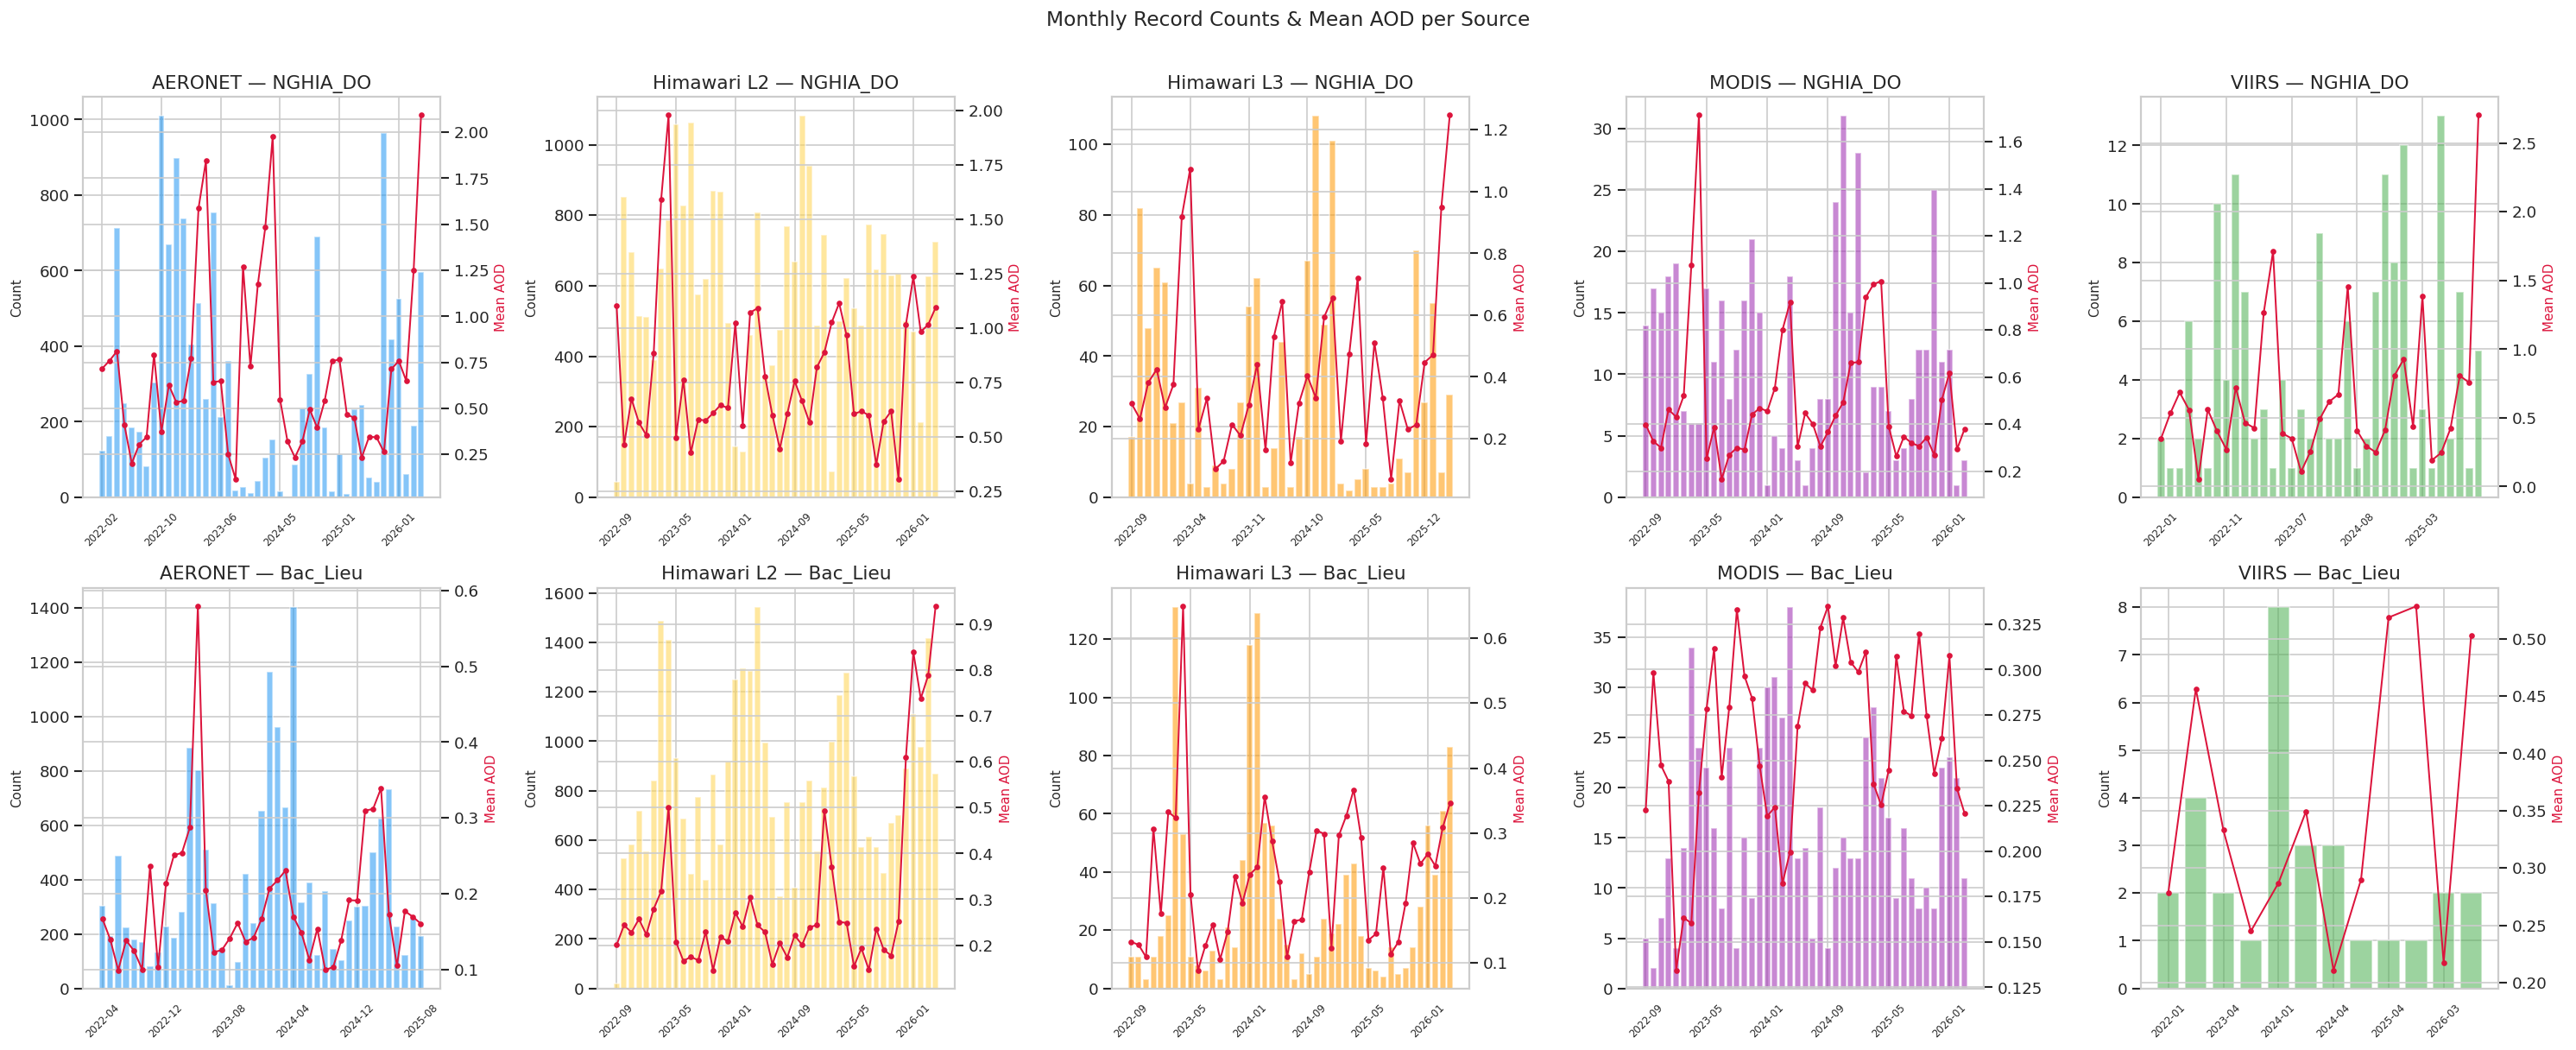

In [75]:
# ── 2.1 Monthly record counts per source per station ──
src_configs = [
    ("AERONET",     aeronet,  "AOD_550"),
    ("Himawari L2", him_l2,   "aod"),
    ("Himawari L3", him_l3,   "aod"),
    ("MODIS",       modis,    "aod"),
    ("VIIRS",       viirs,    "aod"),
]

n_srcs = len(src_configs)
fig, axes = plt.subplots(len(STATIONS), n_srcs, figsize=(5 * n_srcs, 5 * len(STATIONS)))
if len(STATIONS) == 1:
    axes = axes[np.newaxis, :]

for r, site in enumerate(STATIONS):
    for c, (src_name, data_dict, col) in enumerate(src_configs):
        ax = axes[r, c]
        df = data_dict[site].dropna(subset=[col]) if not data_dict[site].empty else pd.DataFrame()
        if df.empty:
            ax.text(0.5, 0.5, "No data", ha="center", transform=ax.transAxes)
            ax.set_title(f"{src_name}\n{site}")
            continue
        df = df.copy()
        df["ym"] = pd.to_datetime(df["datetime"]).dt.to_period("M")
        m = df.groupby("ym").agg(n=(col, "count"), mu=(col, "mean")).reset_index()
        ax2 = ax.twinx()
        color = COLORS.get(src_name.replace(" ", "_"), "steelblue")
        ax.bar(range(len(m)), m["n"], color=color, alpha=0.55)
        ax2.plot(range(len(m)), m["mu"], "o-", color="crimson", ms=3, lw=1.2)
        ax.set_title(f"{src_name} — {site}")
        ax.set_ylabel("Count", fontsize=9)
        ax2.set_ylabel("Mean AOD", color="crimson", fontsize=9)
        ticks = list(range(0, len(m), max(1, len(m) // 5)))
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(m["ym"].iloc[i]) for i in ticks], rotation=45, fontsize=7)

plt.suptitle("Monthly Record Counts & Mean AOD per Source", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

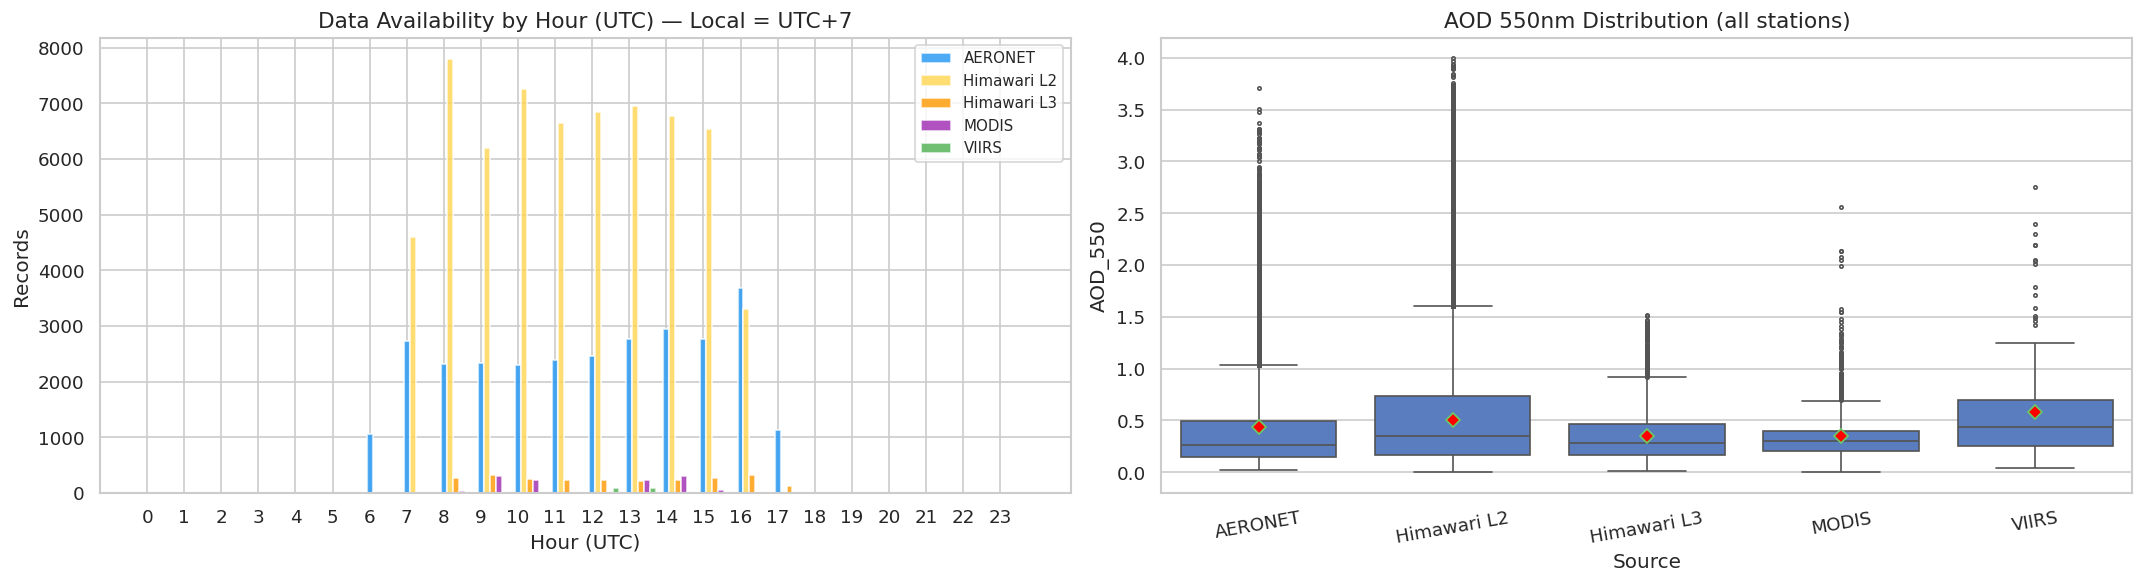


Summary statistics:
               count   mean    std    min    25%    50%    75%    max
Source                                                               
AERONET      28862.0  0.434  0.474  0.026  0.143  0.260  0.498  3.713
Himawari L2  62922.0  0.506  0.477  0.000  0.164  0.354  0.740  3.994
Himawari L3   2466.0  0.352  0.267  0.008  0.163  0.278  0.466  1.517
MODIS         1174.0  0.346  0.264  0.001  0.201  0.298  0.399  2.562
VIIRS          183.0  0.583  0.496  0.038  0.256  0.437  0.699  2.753


In [76]:
# ── 2.2 AOD distributions and diurnal availability ──
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Diurnal availability (all stations pooled)
diurnal_srcs = [
    ("AERONET",    aeronet,  "AOD_550"),
    ("Himawari L2",him_l2,   "aod"),
    ("Himawari L3",him_l3,   "aod"),
    ("MODIS",      modis,    "aod"),
    ("VIIRS",      viirs,    "aod"),
]
color_list = [COLORS["AERONET"], COLORS["Himawari_L2"], COLORS["Himawari_L3"],
              COLORS["MODIS"], COLORS["VIIRS"]]
w = 0.8 / len(diurnal_srcs)
for i, (name, data_dict, col) in enumerate(diurnal_srcs):
    all_dfs = [d for d in data_dict.values() if not d.empty]
    if not all_dfs:
        continue
    combined = pd.concat(all_dfs, ignore_index=True).dropna(subset=[col])
    hrs = pd.to_datetime(combined["datetime"]).dt.hour.value_counts().reindex(range(24), fill_value=0)
    axes[0].bar(np.arange(24) + i * w, hrs.values, w, label=name, color=color_list[i], alpha=0.8)

axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Records")
axes[0].set_title("Data Availability by Hour (UTC) — Local = UTC+7")
axes[0].set_xticks(range(24))
axes[0].legend(fontsize=9)

# AOD distribution box plot
rows = []
for name, data_dict, col in diurnal_srcs:
    all_dfs = [d for d in data_dict.values() if not d.empty]
    if not all_dfs:
        continue
    vals = pd.concat(all_dfs, ignore_index=True)[col].dropna()
    vals = vals[(vals > 0) & (vals < 4)]
    rows.extend([{"Source": name, "AOD_550": v} for v in vals])

df_box = pd.DataFrame(rows)
sns.boxplot(
    data=df_box, x="Source", y="AOD_550", ax=axes[1],
    fliersize=2, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "red", "ms": 6},
)
axes[1].set_title("AOD 550nm Distribution (all stations)")
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

print("\nSummary statistics:")
print(df_box.groupby("Source")["AOD_550"].describe().round(3).to_string())

## 3. Time Matching Functions

Standard AOD validation (Ichoku et al. 2002, Levy et al. 2010):
- **L2 matching**: For each satellite observation, average AERONET within ±30 min
- **L3/daily matching**: Aggregate both sources to daily means, then inner-join on date

In [77]:
def match_l2_to_aeronet(df_sat: pd.DataFrame, df_aer: pd.DataFrame,
                         window_min: int = TIME_WINDOW_MIN) -> pd.DataFrame:
    """
    For each satellite L2 observation, find AERONET mean AOD within ±window_min.
    df_sat must have columns: datetime, aod
    df_aer must have columns: datetime, AOD_550
    """
    window = pd.Timedelta(minutes=window_min)
    aer = (df_aer[["datetime", "AOD_550"]]
           .dropna()
           .set_index("datetime")
           .sort_index())
    records = []
    for _, row in df_sat.dropna(subset=["aod"]).iterrows():
        t = row["datetime"]
        window_data = aer.loc[t - window : t + window, "AOD_550"]
        if len(window_data) >= 1:
            records.append({
                "datetime": t,
                "date":     t.date(),
                "sat_aod":  row["aod"],
                "aer_aod":  window_data.mean(),
                "aer_std":  window_data.std() if len(window_data) > 1 else 0.0,
                "aer_n":    len(window_data),
            })
    return pd.DataFrame(records)


def match_daily_to_aeronet(df_sat: pd.DataFrame, df_aer: pd.DataFrame,
                            sat_col: str = "aod") -> pd.DataFrame:
    """
    Aggregate both sources to daily means, inner-join on date.
    """
    aer_daily = (df_aer.dropna(subset=["AOD_550"])
                 .groupby("date")["AOD_550"]
                 .agg(["mean", "std", "count"])
                 .reset_index()
                 .rename(columns={"mean": "aer_aod", "std": "aer_std", "count": "aer_n"}))
    sat_daily = (df_sat.dropna(subset=[sat_col])
                 .groupby("date")[sat_col]
                 .mean()
                 .reset_index()
                 .rename(columns={sat_col: "sat_aod"}))
    merged = aer_daily.merge(sat_daily, on="date").dropna()
    merged["datetime"] = pd.to_datetime(merged["date"])
    return merged


def compute_metrics(aer: np.ndarray, sat: np.ndarray) -> dict:
    """Standard AOD validation metrics."""
    mask = np.isfinite(aer) & np.isfinite(sat)
    x, y = aer[mask], sat[mask]
    n = len(x)
    if n < 3:
        return {"N": n}
    slope, intercept, r, p, _ = stats.linregress(x, y)
    rmse = np.sqrt(np.mean((y - x) ** 2))
    mae  = np.mean(np.abs(y - x))
    bias = np.mean(y - x)
    # EE envelope: ±(0.05 + 0.15·AOD_AERONET)
    within_ee = np.mean(np.abs(y - x) <= 0.05 + 0.15 * x) * 100
    return {
        "N": n, "R": r, "R²": r**2,
        "RMSE": rmse, "MAE": mae, "Bias": bias,
        "Slope": slope, "Intercept": intercept,
        "%EE": within_ee, "p_value": p,
    }


print("Time matching functions defined.")

Time matching functions defined.


In [78]:
# ── 3.1 Run time matching for all stations ──
matched = {}  # matched[station][source] = DataFrame

for site in STATIONS:
    df_aer = aeronet[site]
    if df_aer.empty:
        print(f"{site}: no AERONET → skip")
        continue

    matched[site] = {}
    print(f"\n{site} ({STATIONS[site]['city']}):")

    # Himawari L2 → ±30 min
    df_h2 = him_l2[site].dropna(subset=["aod"]) if not him_l2[site].empty else pd.DataFrame()
    if not df_h2.empty:
        m = match_l2_to_aeronet(df_h2, df_aer)
        matched[site]["Himawari L2"] = m
        print(f"  Himawari L2  (±{TIME_WINDOW_MIN}min): {len(m):,} pairs")
    else:
        print(f"  Himawari L2: no valid AOD")

    # MODIS → ±30 min
    df_mod = modis[site]
    if not df_mod.empty:
        m = match_l2_to_aeronet(df_mod, df_aer)
        matched[site]["MODIS"] = m
        print(f"  MODIS        (±{TIME_WINDOW_MIN}min): {len(m):,} pairs")
    else:
        print(f"  MODIS: no data")

    # VIIRS → ±30 min
    df_v = viirs[site]
    if not df_v.empty:
        m = match_l2_to_aeronet(df_v, df_aer)
        matched[site]["VIIRS"] = m
        print(f"  VIIRS        (±{TIME_WINDOW_MIN}min): {len(m):,} pairs  [{viirs_method[site]}]")
    else:
        print(f"  VIIRS: no data")

    # Himawari L3 → daily
    df_h3 = him_l3[site].dropna(subset=["aod"]) if not him_l3[site].empty else pd.DataFrame()
    if not df_h3.empty:
        m = match_daily_to_aeronet(df_h3, df_aer)
        matched[site]["Himawari L3"] = m
        print(f"  Himawari L3  (daily):     {len(m):,} days")
    else:
        print(f"  Himawari L3: no valid AOD")


NGHIA_DO (Hanoi):
  Himawari L2  (±30min): 9,756 pairs
  MODIS        (±30min): 239 pairs
  VIIRS        (±30min): 103 pairs  [nearest_pixel]
  Himawari L3  (daily):     178 days

Bac_Lieu (Bac Lieu):
  Himawari L2  (±30min): 14,092 pairs
  MODIS        (±30min): 413 pairs
  VIIRS        (±30min): 23 pairs  [nearest_pixel]
  Himawari L3  (daily):     289 days


## 4. Scatter Validation: Satellite vs AERONET

In [79]:
def plot_scatter_panel(pairs_dict: dict, station: str, title_prefix: str = ""):
    """Scatter plots for all matched sources at a station."""
    valid = {k: v for k, v in pairs_dict.items() if len(v) >= 3}
    if not valid:
        print(f"  No pairs to plot for {station}.")
        return {}

    ncols = min(3, len(valid))
    nrows = (len(valid) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 6 * nrows))
    axes = np.atleast_1d(axes).flatten()
    all_metrics = {}

    for ax, (src, df_m) in zip(axes, valid.items()):
        x = df_m["aer_aod"].values
        y = df_m["sat_aod"].values
        m = compute_metrics(x, y)
        all_metrics[src] = m

        lim = max(x.max(), y.max()) * 1.12
        xl  = np.linspace(0, lim, 100)

        ax.fill_between(xl, xl - 0.05 - 0.15*xl, xl + 0.05 + 0.15*xl,
                        alpha=0.12, color="gray", label="EE ±(0.05+15%)")
        ax.plot(xl, xl, "k--", lw=1, alpha=0.4, label="1:1")
        ax.scatter(x, y, s=12, alpha=0.45,
                   color=COLORS.get(src.replace(" ", "_"), "gray"), edgecolors="none")
        ax.plot(xl, m["Slope"]*xl + m["Intercept"], "r-", lw=1.5,
                label=f"y={m['Slope']:.2f}x{m['Intercept']:+.3f}")

        ax.set(xlabel="AERONET AOD 550nm", ylabel=f"{src} AOD 550nm",
               xlim=(0, lim), ylim=(0, lim), aspect="equal")
        ax.set_title(
            f"{title_prefix}{src} — {station} (N={m['N']}\n"
            f"R={m['R']:.3f}  RMSE={m['RMSE']:.3f}  "
            f"Bias={m['Bias']:+.3f}  EE={m['%EE']:.0f}%"
        )
        ax.legend(fontsize=7, loc="upper left")

    for ax in axes[len(valid):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return all_metrics


print("Scatter plot function defined.")

Scatter plot function defined.



L2-LEVEL VALIDATION  |  NGHIA_DO (Hanoi)


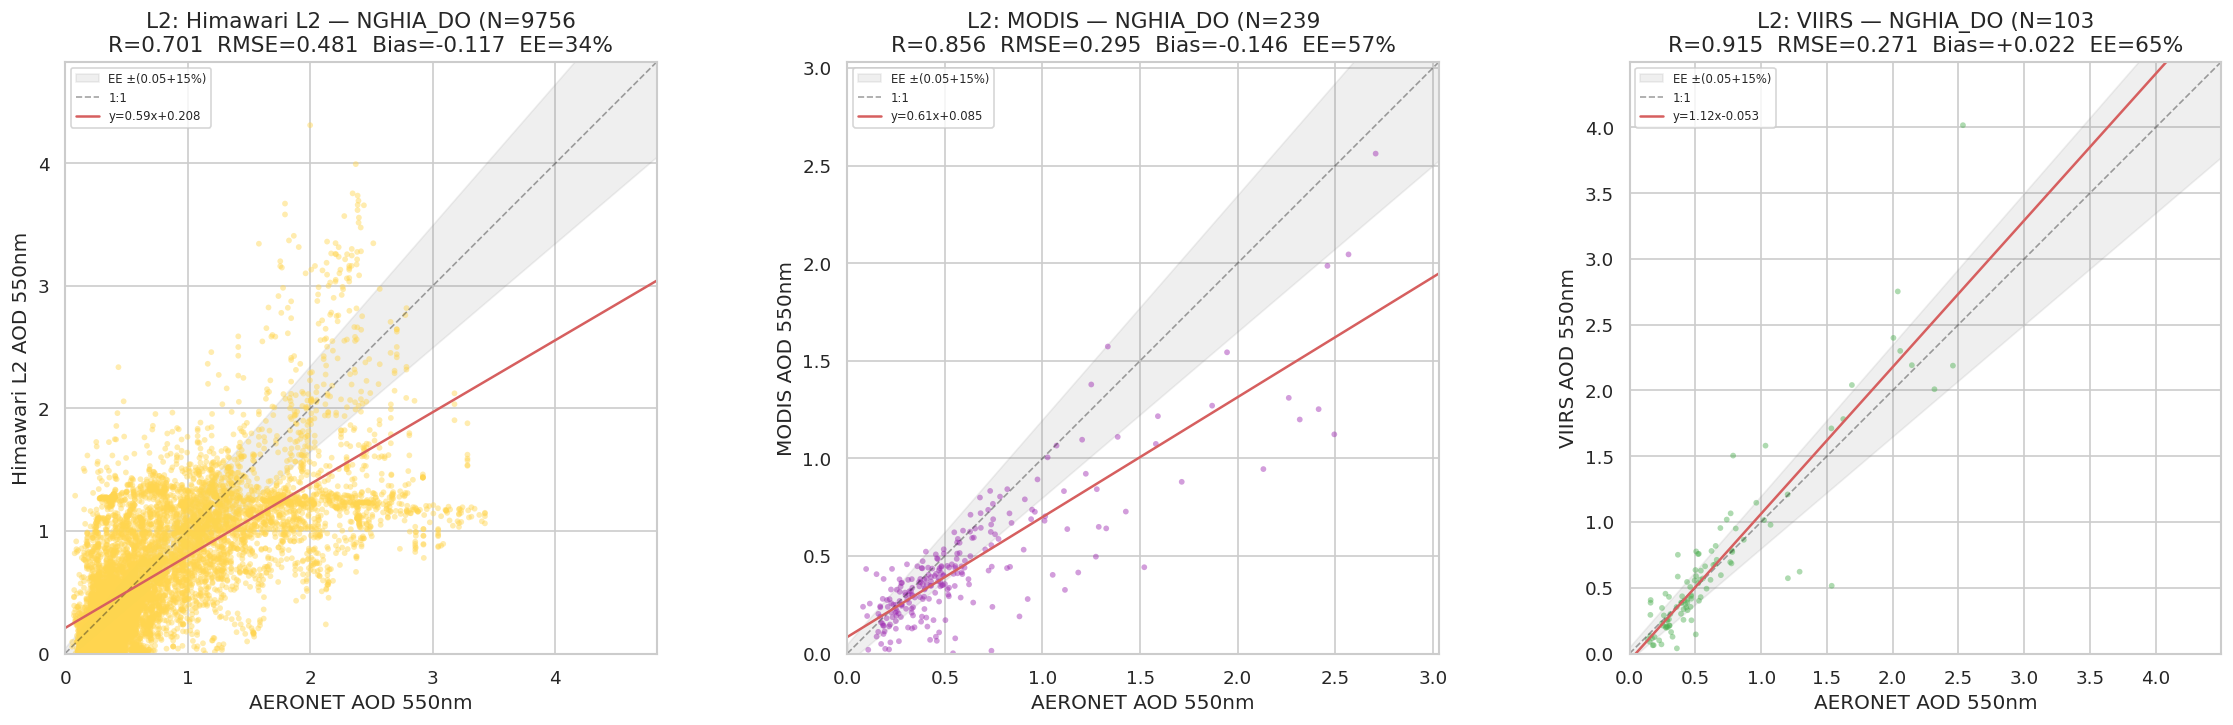


L2-LEVEL VALIDATION  |  Bac_Lieu (Bac Lieu)


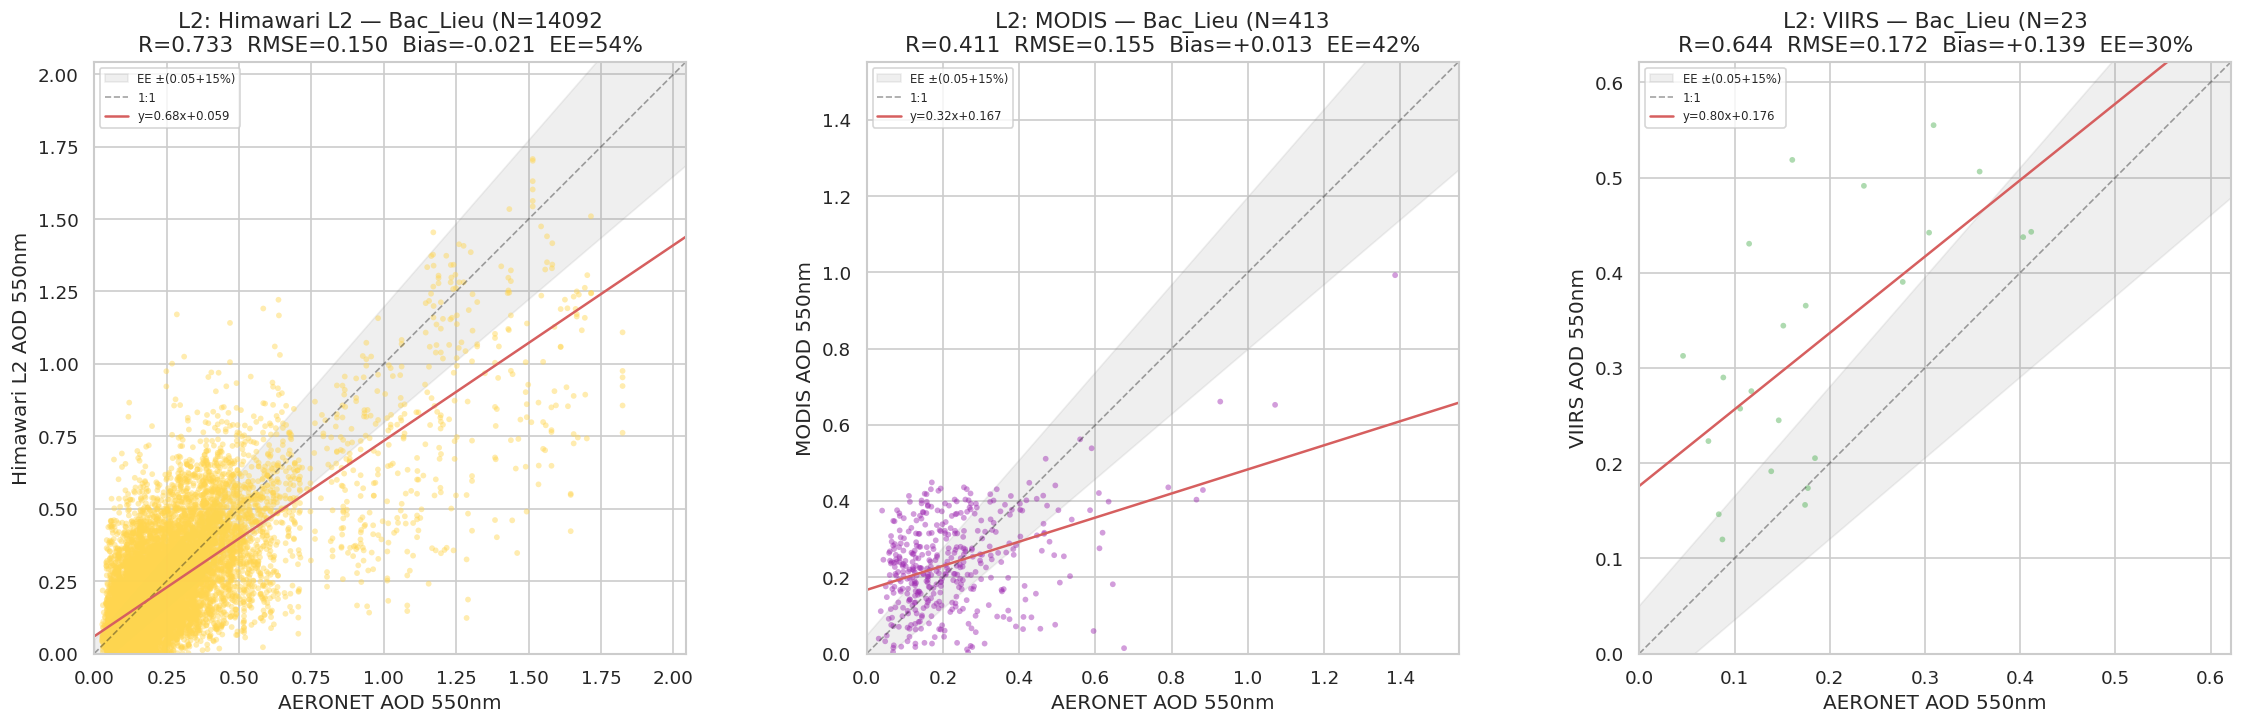

In [80]:
# ── 4.1 L2-level scatter plots (Himawari L2 + MODIS + VIIRS vs AERONET) ──
all_metrics = {}

for site in STATIONS:
    if site not in matched:
        continue
    l2_pairs = {k: v for k, v in matched[site].items() if k in ("Himawari L2", "MODIS", "VIIRS")}
    print(f"\n{'='*60}")
    print(f"L2-LEVEL VALIDATION  |  {site} ({STATIONS[site]['city']})")
    print(f"{'='*60}")
    m = plot_scatter_panel(l2_pairs, site, title_prefix="L2: ")
    if m:
        all_metrics.setdefault(site, {}).update({f"{k} (L2)": v for k, v in m.items()})


L3-LEVEL VALIDATION  |  NGHIA_DO (Hanoi)


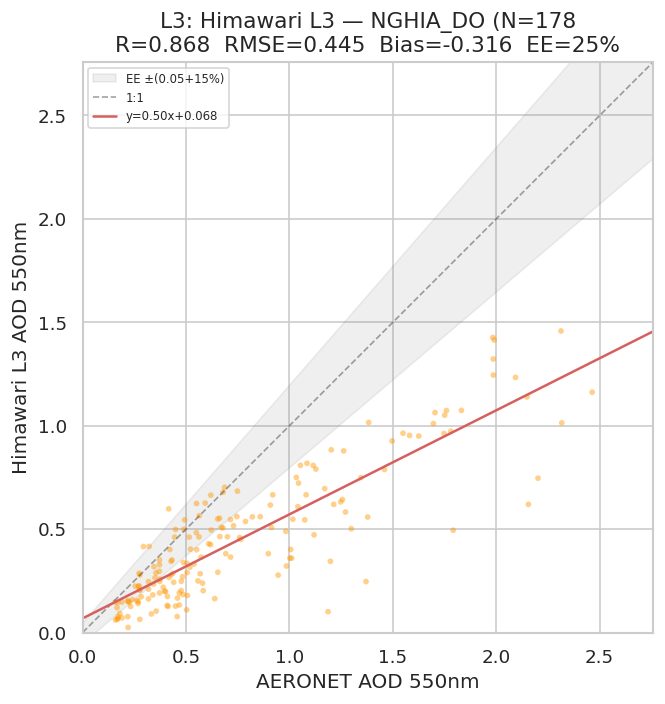


L3-LEVEL VALIDATION  |  Bac_Lieu (Bac Lieu)


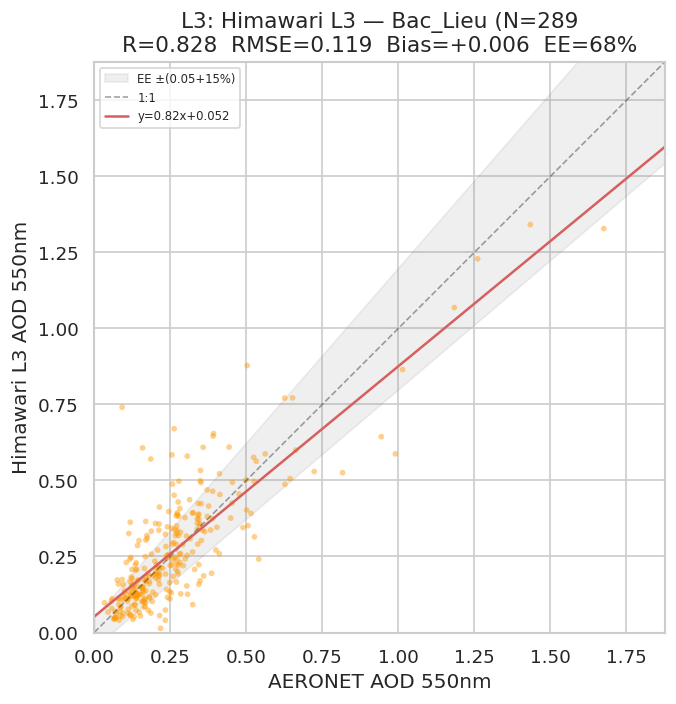

In [81]:
# ── 4.2 L3-level scatter plots (Himawari L3 vs AERONET daily) ──
for site in STATIONS:
    if site not in matched:
        continue
    l3_pairs = {k: v for k, v in matched[site].items() if k == "Himawari L3"}
    print(f"\n{'='*60}")
    print(f"L3-LEVEL VALIDATION  |  {site} ({STATIONS[site]['city']})")
    print(f"{'='*60}")
    m = plot_scatter_panel(l3_pairs, site, title_prefix="L3: ")
    if m:
        all_metrics.setdefault(site, {}).update({f"{k} (L3)": v for k, v in m.items()})

## 5. Density Scatter & Residual Analysis

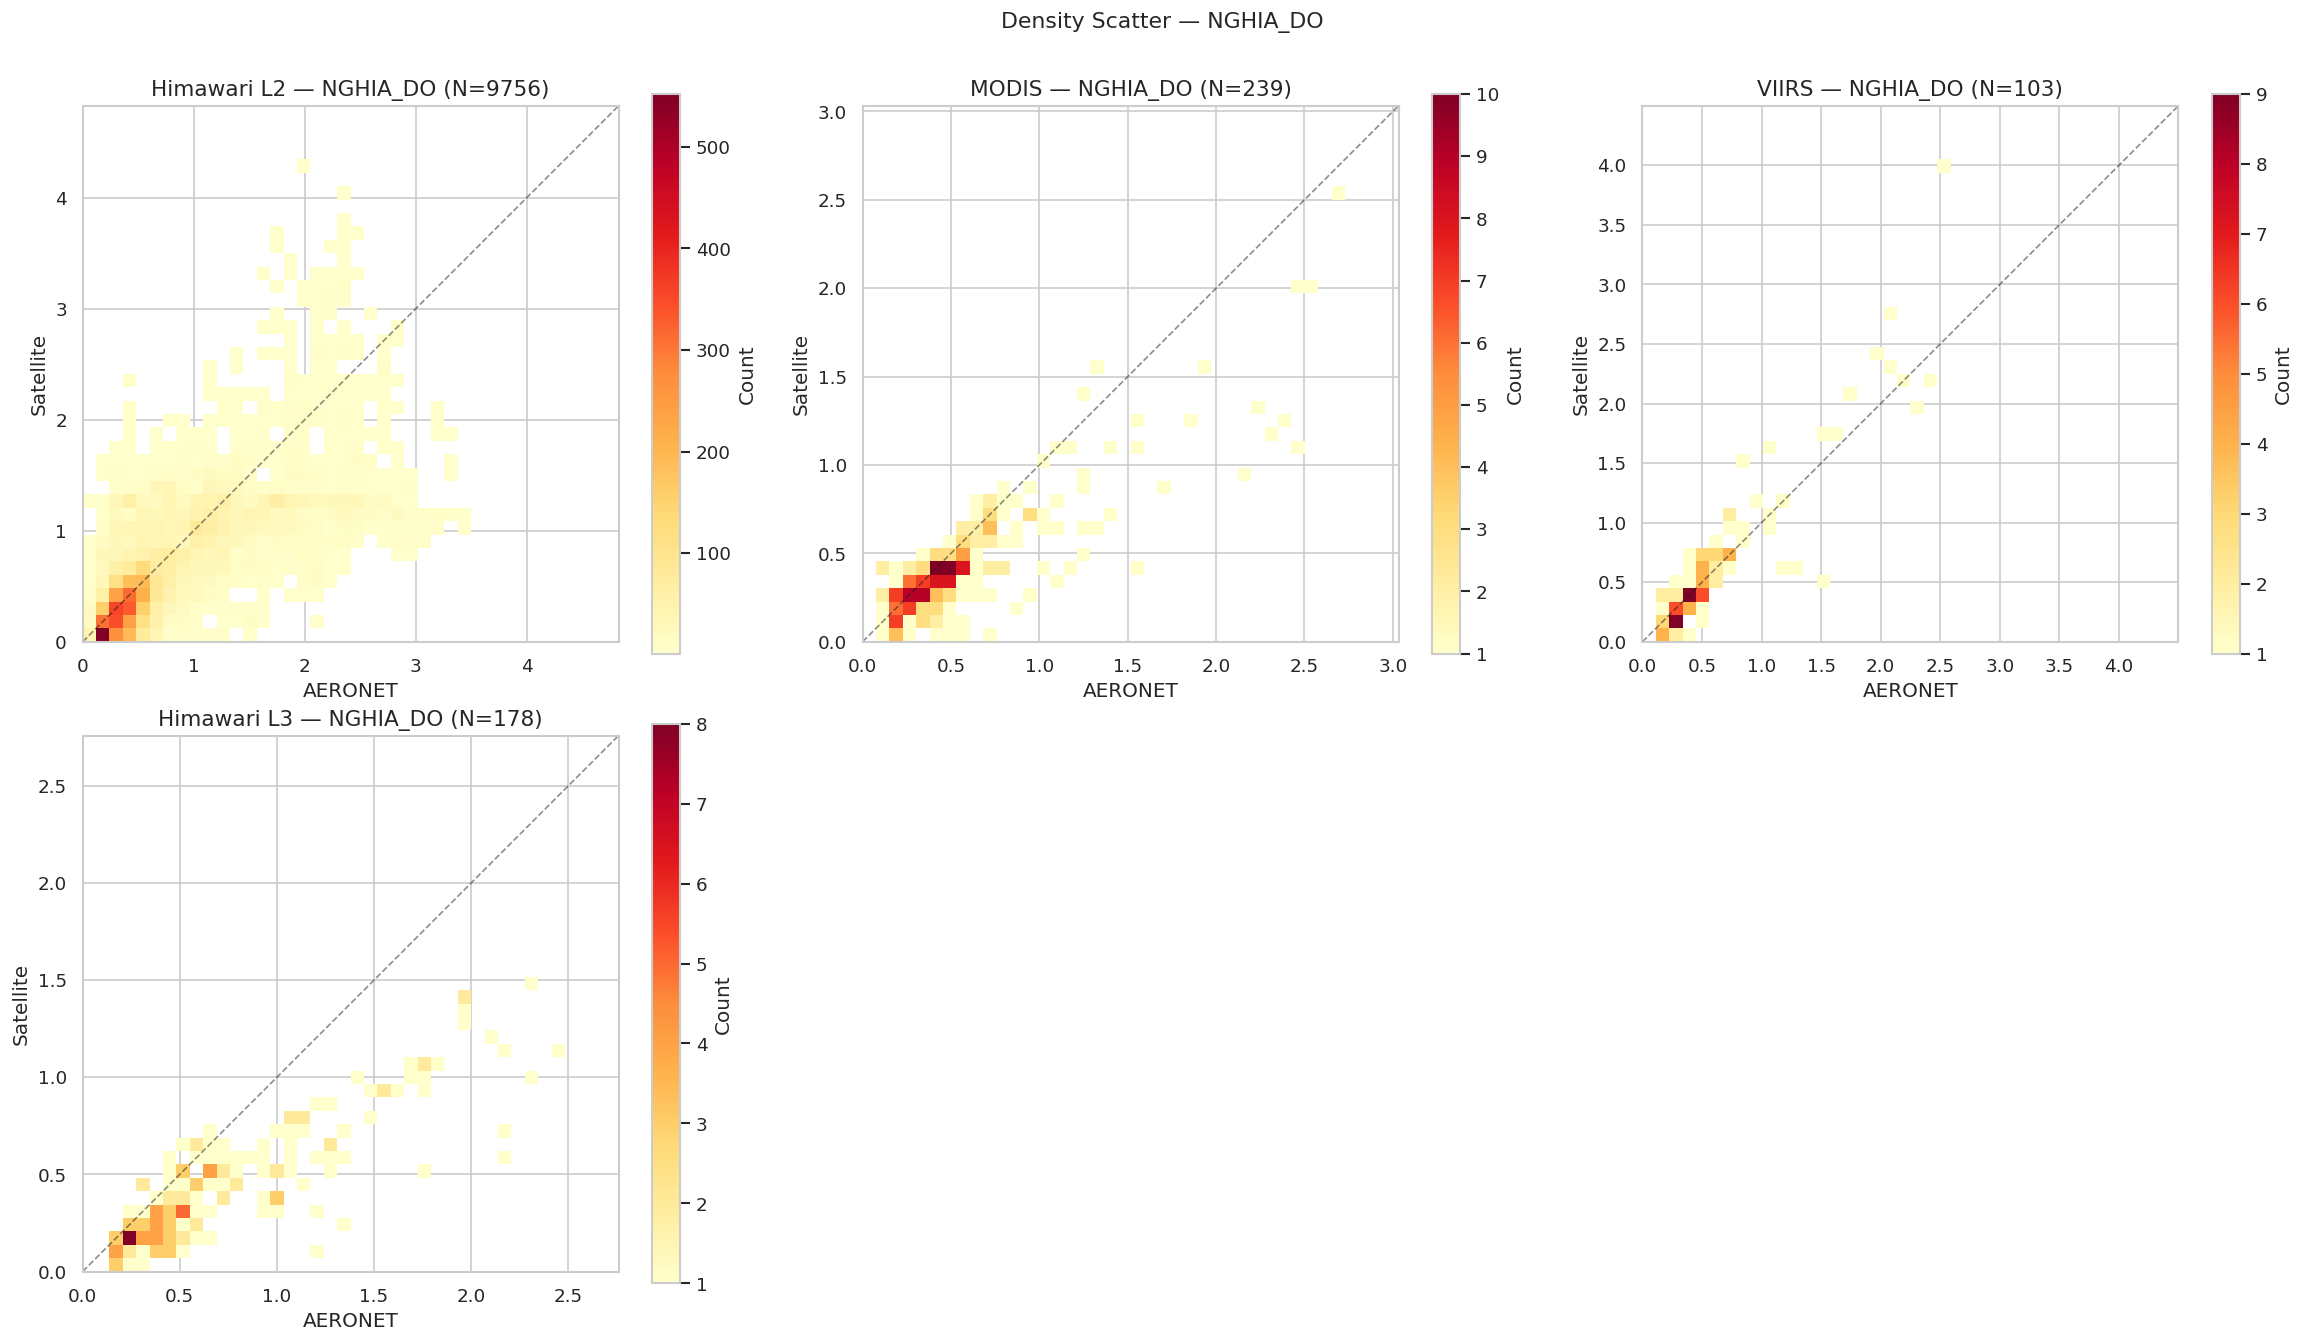

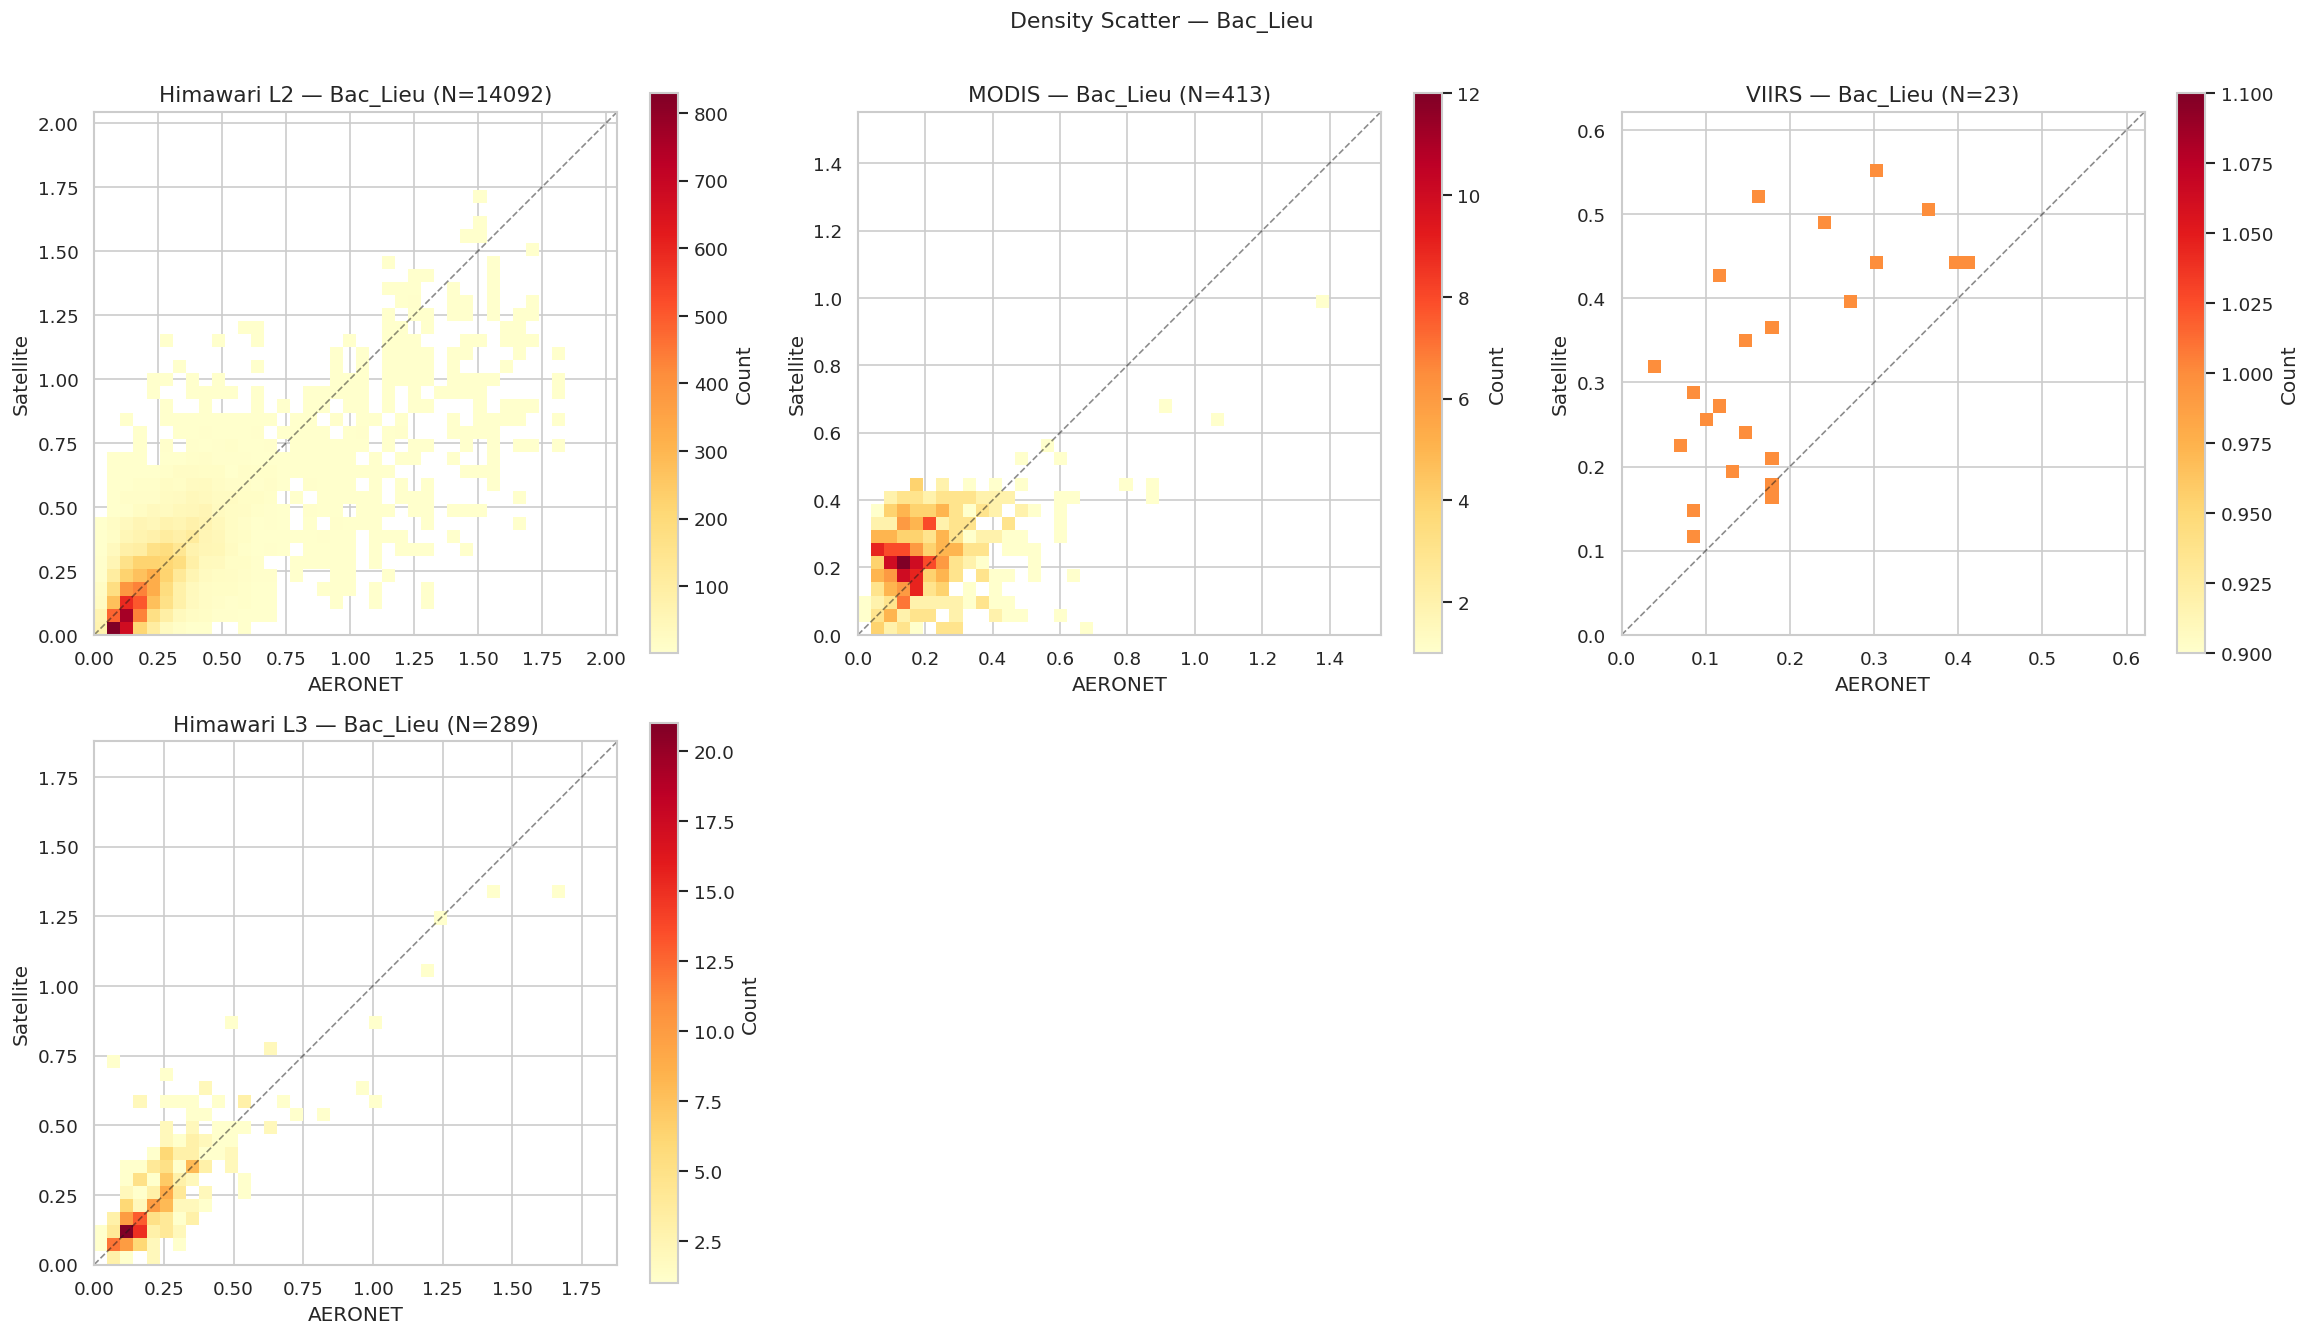

In [82]:
# ── 5.1 2D histogram density scatter ──
for site in STATIONS:
    if site not in matched:
        continue
    valid = {k: v for k, v in matched[site].items() if len(v) >= 20}
    if not valid:
        continue
    ncols = min(3, len(valid))
    nrows = (len(valid) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, (src, df_m) in zip(axes, valid.items()):
        x, y = df_m["aer_aod"].values, df_m["sat_aod"].values
        lim = max(x.max(), y.max()) * 1.12
        h = ax.hist2d(x, y, bins=40, range=[[0, lim], [0, lim]], cmap="YlOrRd", cmin=1)
        plt.colorbar(h[3], ax=ax, label="Count")
        ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5)
        ax.set(xlabel="AERONET", ylabel="Satellite",
               title=f"{src} — {site} (N={len(x)})", aspect="equal")
    for ax in axes[len(valid):]:
        ax.axis("off")
    plt.suptitle(f"Density Scatter — {site}", y=1.01)
    plt.tight_layout()
    plt.show()

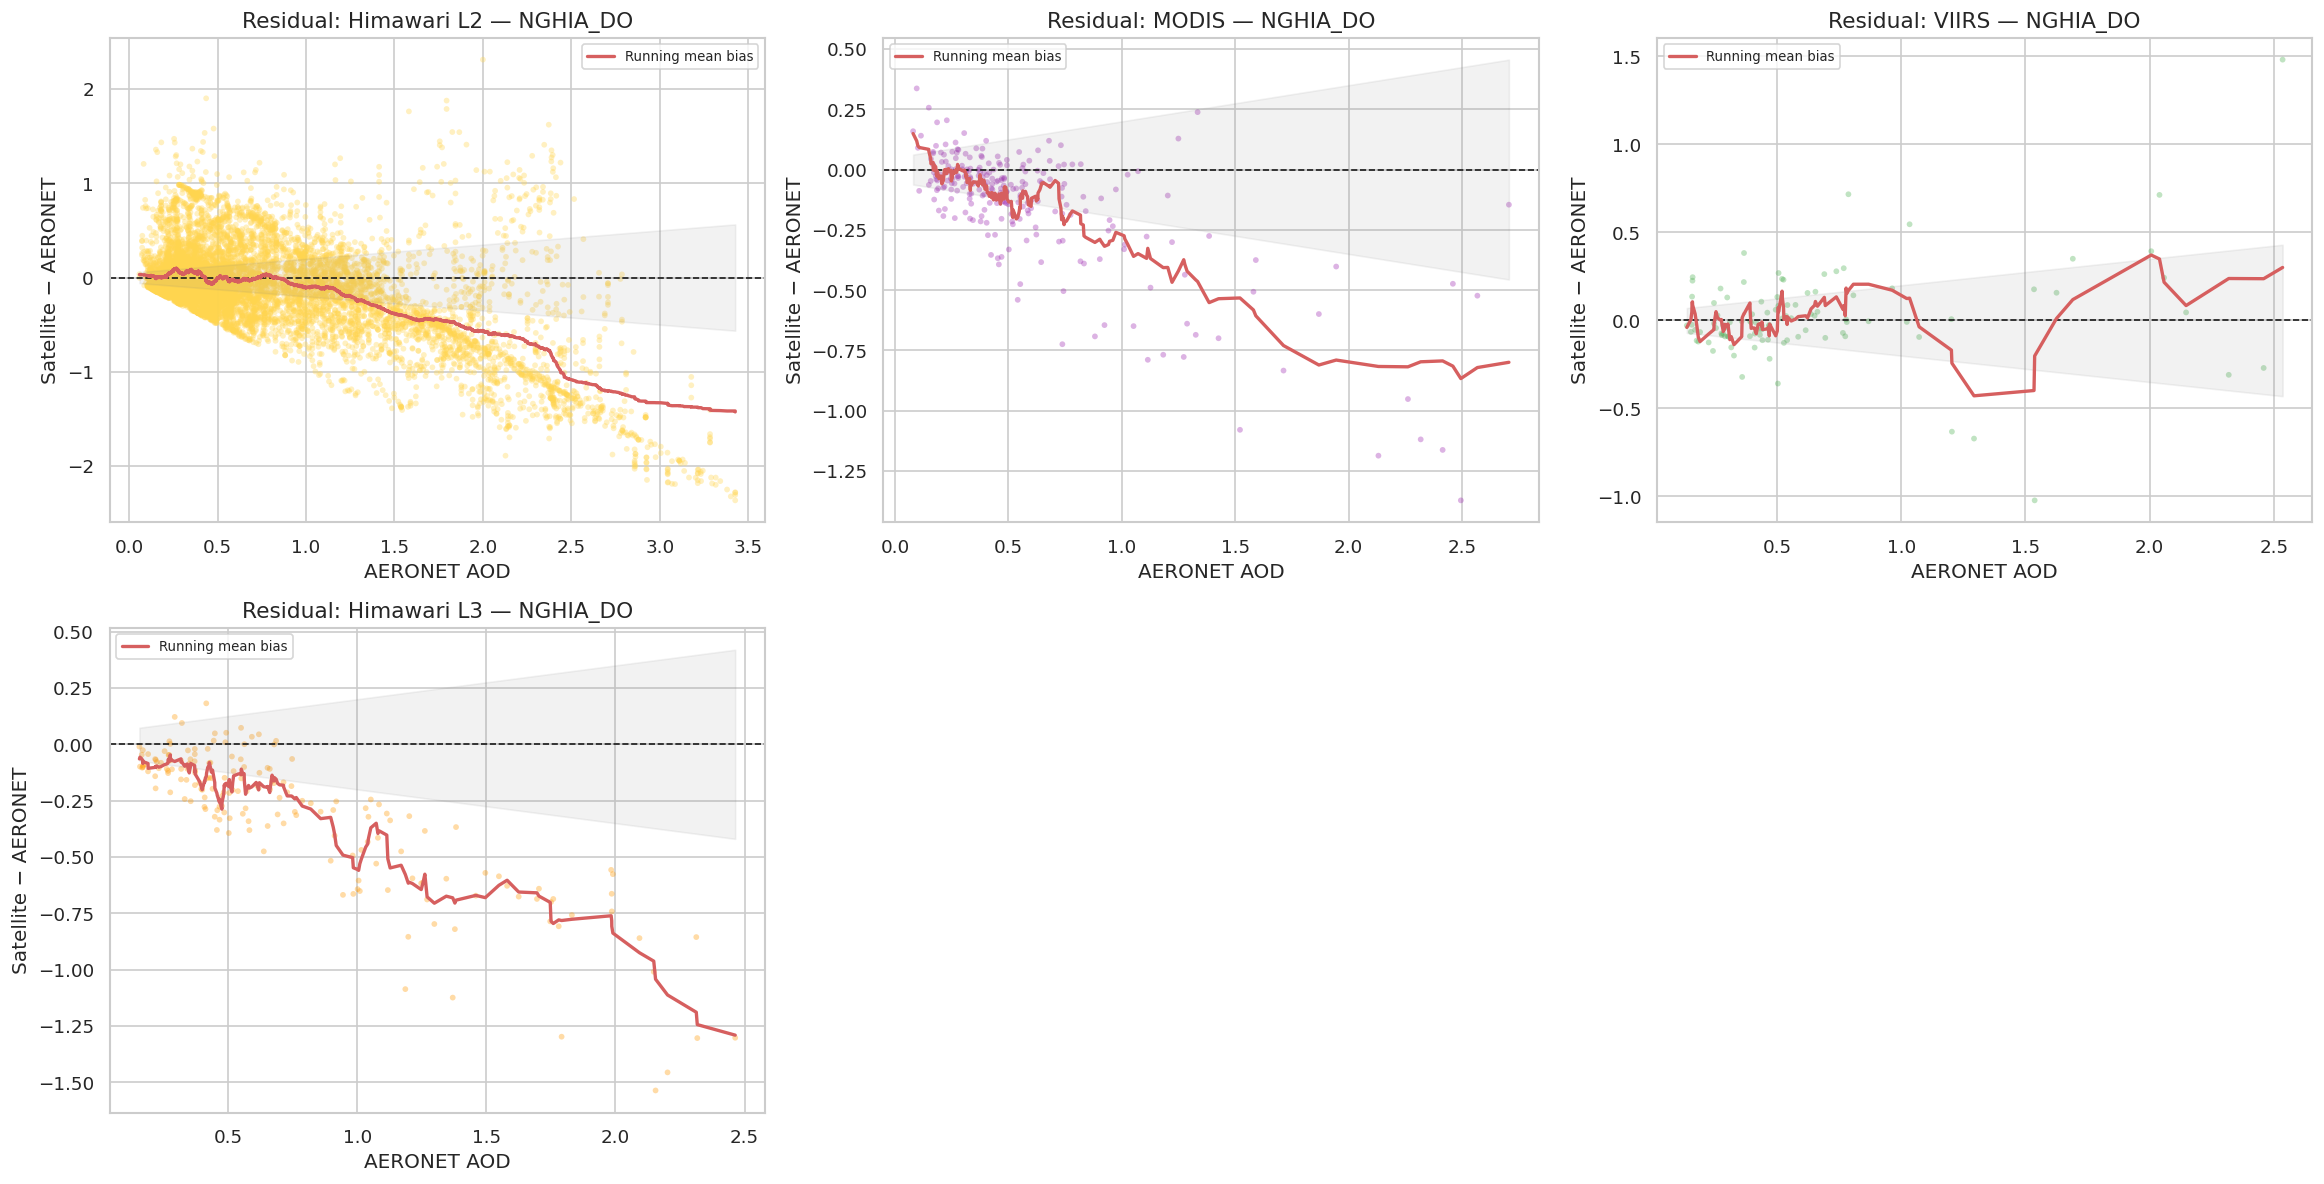

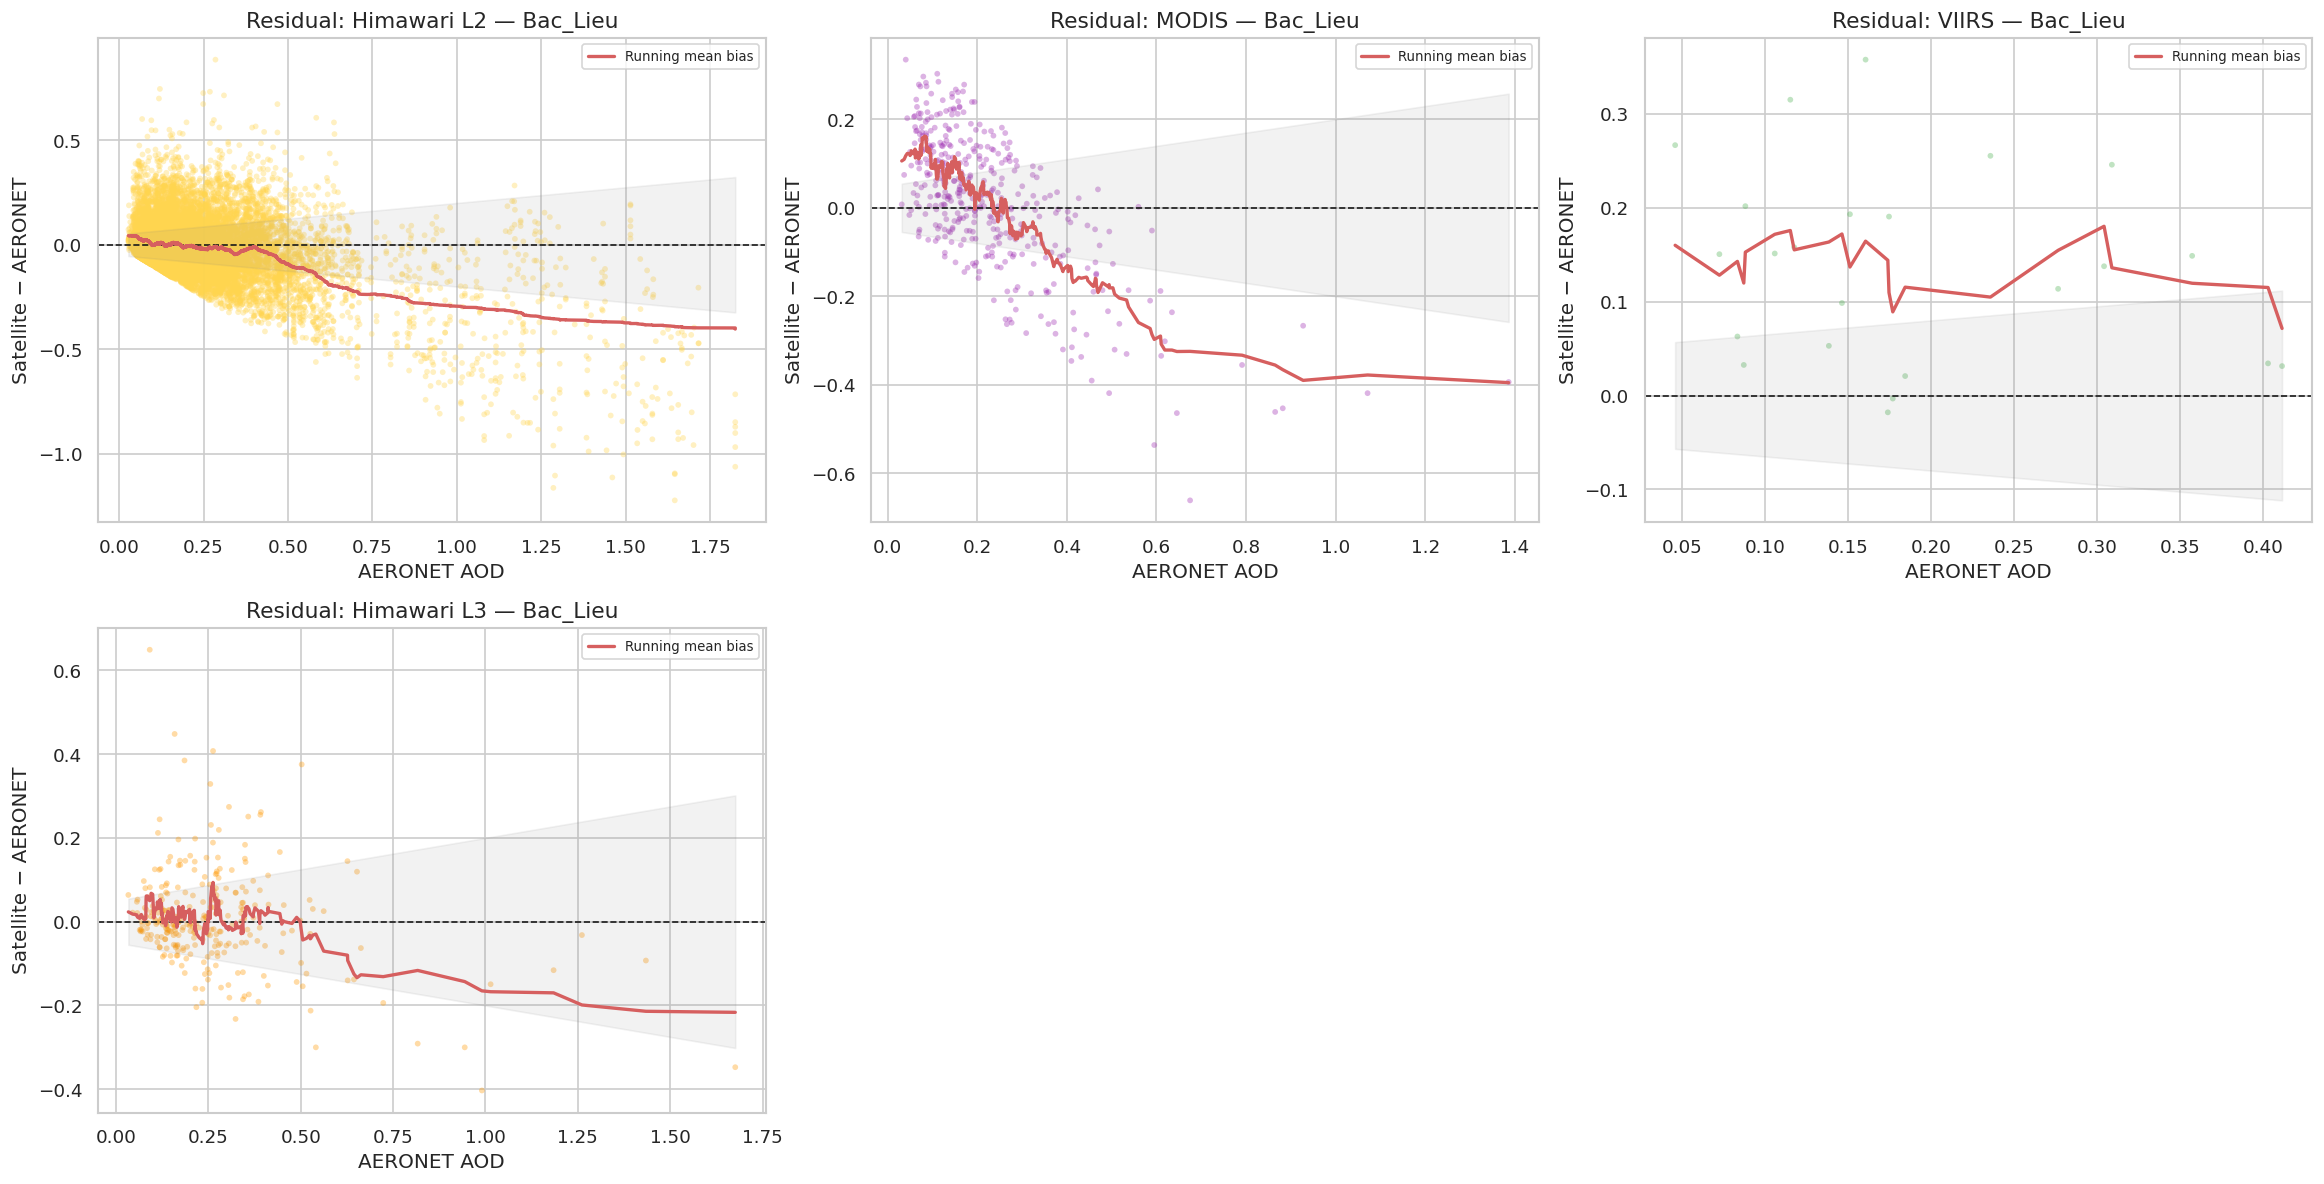

In [83]:
# ── 5.2 Residual (bias) analysis ──
for site in STATIONS:
    if site not in matched:
        continue
    valid = {k: v for k, v in matched[site].items() if len(v) >= 20}
    if not valid:
        continue
    ncols = min(3, len(valid))
    nrows = (len(valid) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, (src, df_m) in zip(axes, valid.items()):
        x = df_m["aer_aod"].values
        res = df_m["sat_aod"].values - x
        ax.scatter(x, res, s=12, alpha=0.35, edgecolors="none",
                   color=COLORS.get(src.replace(" ", "_"), "gray"))
        ax.axhline(0, color="k", ls="--", lw=1)
        # Running mean bias
        order = np.argsort(x)
        xs, rs = x[order], res[order]
        win = max(len(xs) // 20, 5)
        rm = pd.Series(rs).rolling(win, min_periods=3, center=True).mean()
        ax.plot(xs, rm.values, "r-", lw=2, label="Running mean bias")
        ax.fill_between(xs, -0.05 - 0.15*xs, 0.05 + 0.15*xs, alpha=0.1, color="gray")
        ax.set(xlabel="AERONET AOD", ylabel="Satellite − AERONET",
               title=f"Residual: {src} — {site}")
        ax.legend(fontsize=8)
    for ax in axes[len(valid):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 6. Time Series Comparison

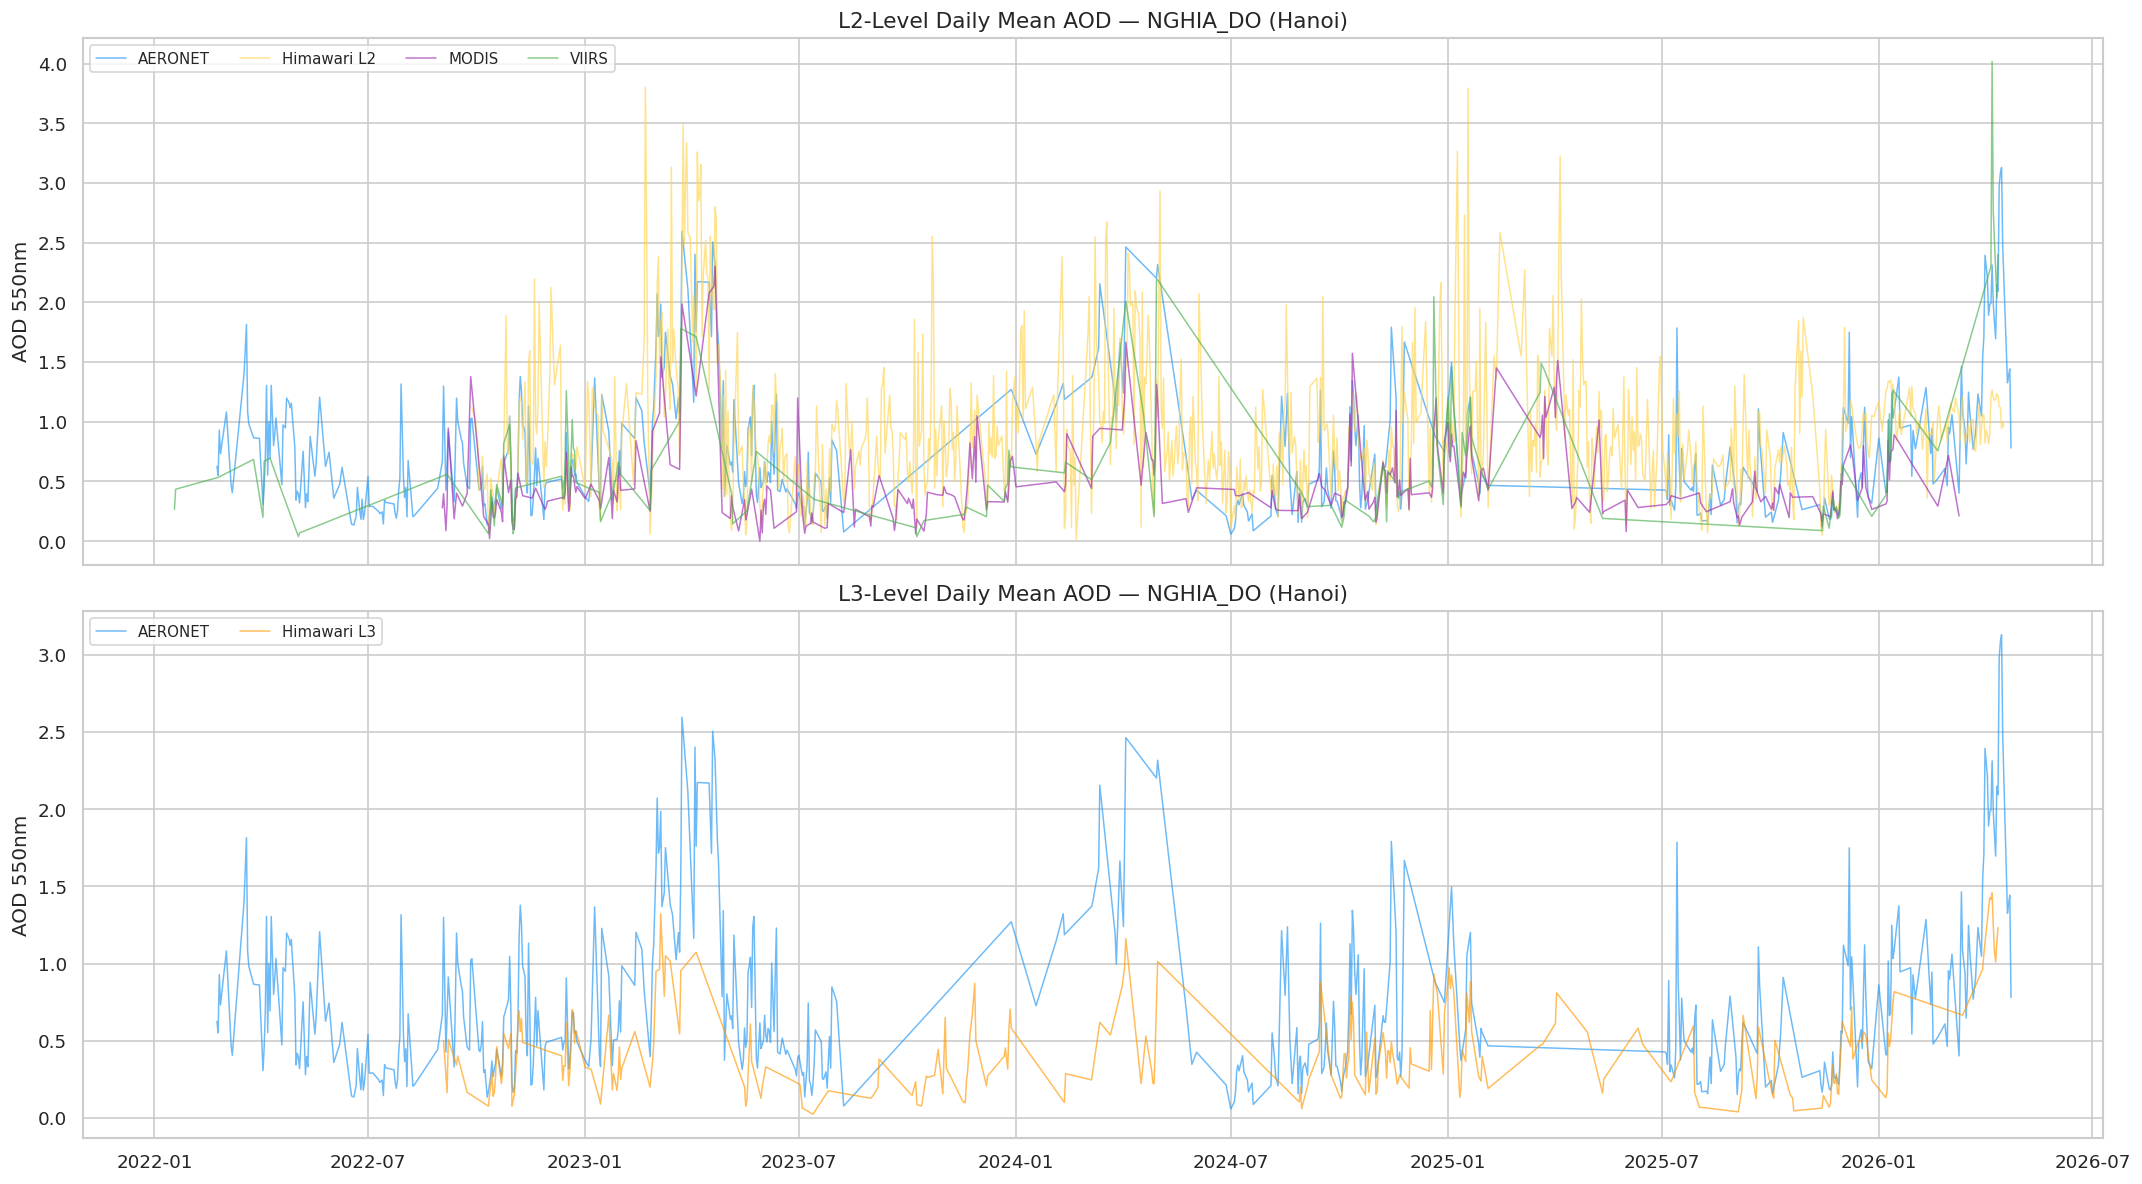

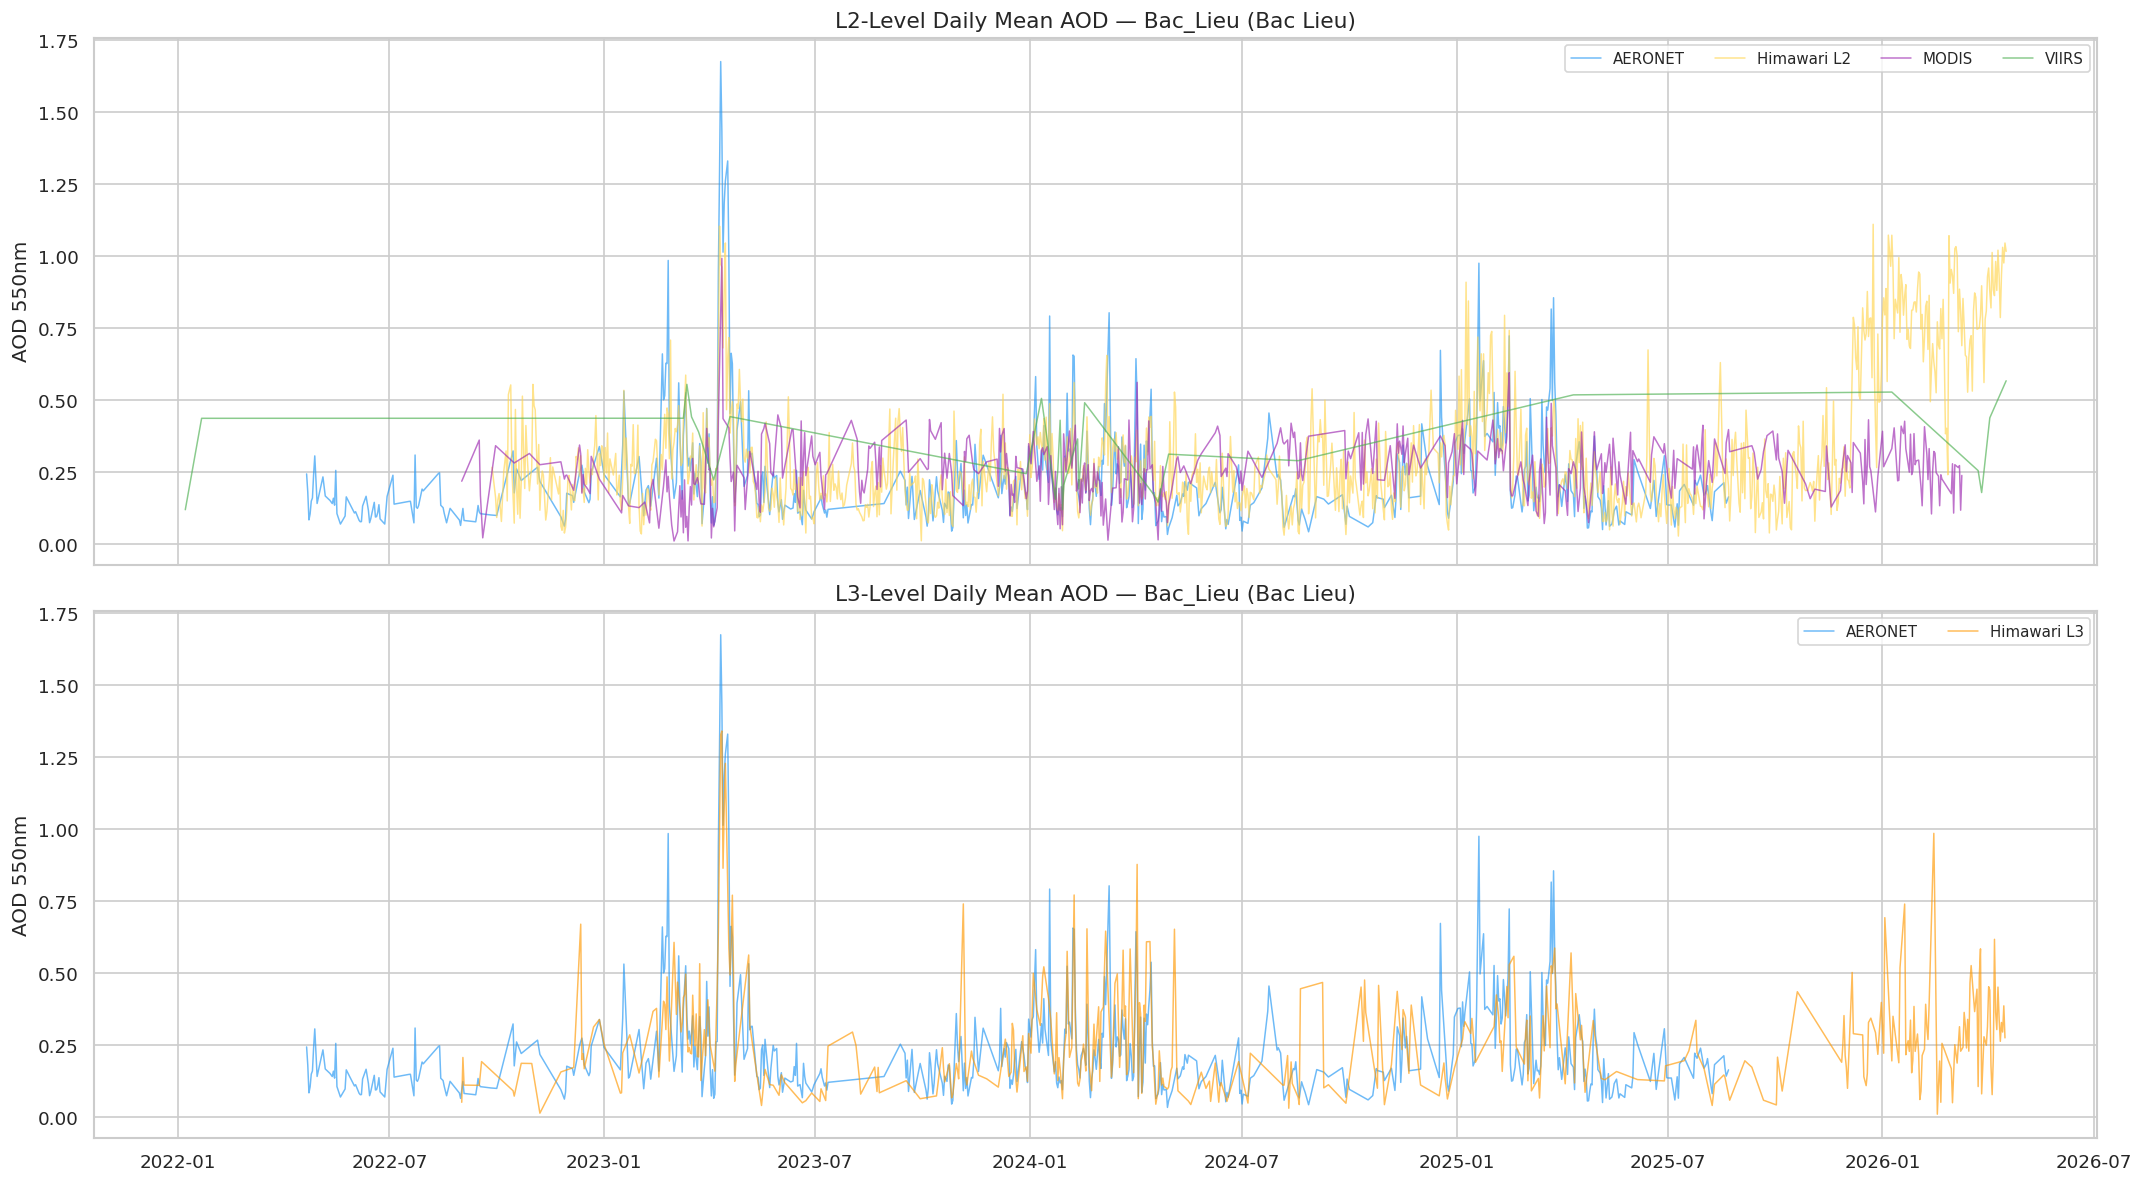

In [84]:
# ── 6.1 Daily mean time series per station ──
def make_daily_series(df: pd.DataFrame, col: str, src: str) -> pd.DataFrame:
    d = df.dropna(subset=[col]).copy()
    d["date_dt"] = pd.to_datetime(d["date"])
    daily = d.groupby("date_dt")[col].mean().reset_index()
    daily.columns = ["date", "aod"]
    daily["source"] = src
    return daily


for site in STATIONS:
    df_aer = aeronet[site]
    if df_aer.empty:
        continue

    daily_parts = {
        "AERONET":     make_daily_series(df_aer,        "AOD_550", "AERONET"),
    }
    if not him_l2[site].empty:
        daily_parts["Himawari L2"] = make_daily_series(him_l2[site], "aod", "Himawari L2")
    if not him_l3[site].empty:
        daily_parts["Himawari L3"] = make_daily_series(him_l3[site], "aod", "Himawari L3")
    if not modis[site].empty:
        daily_parts["MODIS"] = make_daily_series(modis[site], "aod", "MODIS")
    if not viirs[site].empty:
        daily_parts["VIIRS"] = make_daily_series(viirs[site], "aod", "VIIRS")

    l2_srcs = ["AERONET", "Himawari L2", "MODIS", "VIIRS"]
    l3_srcs = ["AERONET", "Himawari L3"]

    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
    for src in l2_srcs:
        if src in daily_parts:
            d = daily_parts[src]
            axes[0].plot(d["date"], d["aod"], lw=0.9, alpha=0.65,
                         color=COLORS.get(src.replace(" ", "_"), "gray"), label=src)
    axes[0].set_title(f"L2-Level Daily Mean AOD — {site} ({STATIONS[site]['city']})")
    axes[0].set_ylabel("AOD 550nm")
    axes[0].legend(ncol=4, fontsize=9)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    for src in l3_srcs:
        if src in daily_parts:
            d = daily_parts[src]
            axes[1].plot(d["date"], d["aod"], lw=0.9, alpha=0.65,
                         color=COLORS.get(src.replace(" ", "_"), "gray"), label=src)
    axes[1].set_title(f"L3-Level Daily Mean AOD — {site} ({STATIONS[site]['city']})")
    axes[1].set_ylabel("AOD 550nm")
    axes[1].legend(ncol=2, fontsize=9)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.tight_layout()
    plt.show()

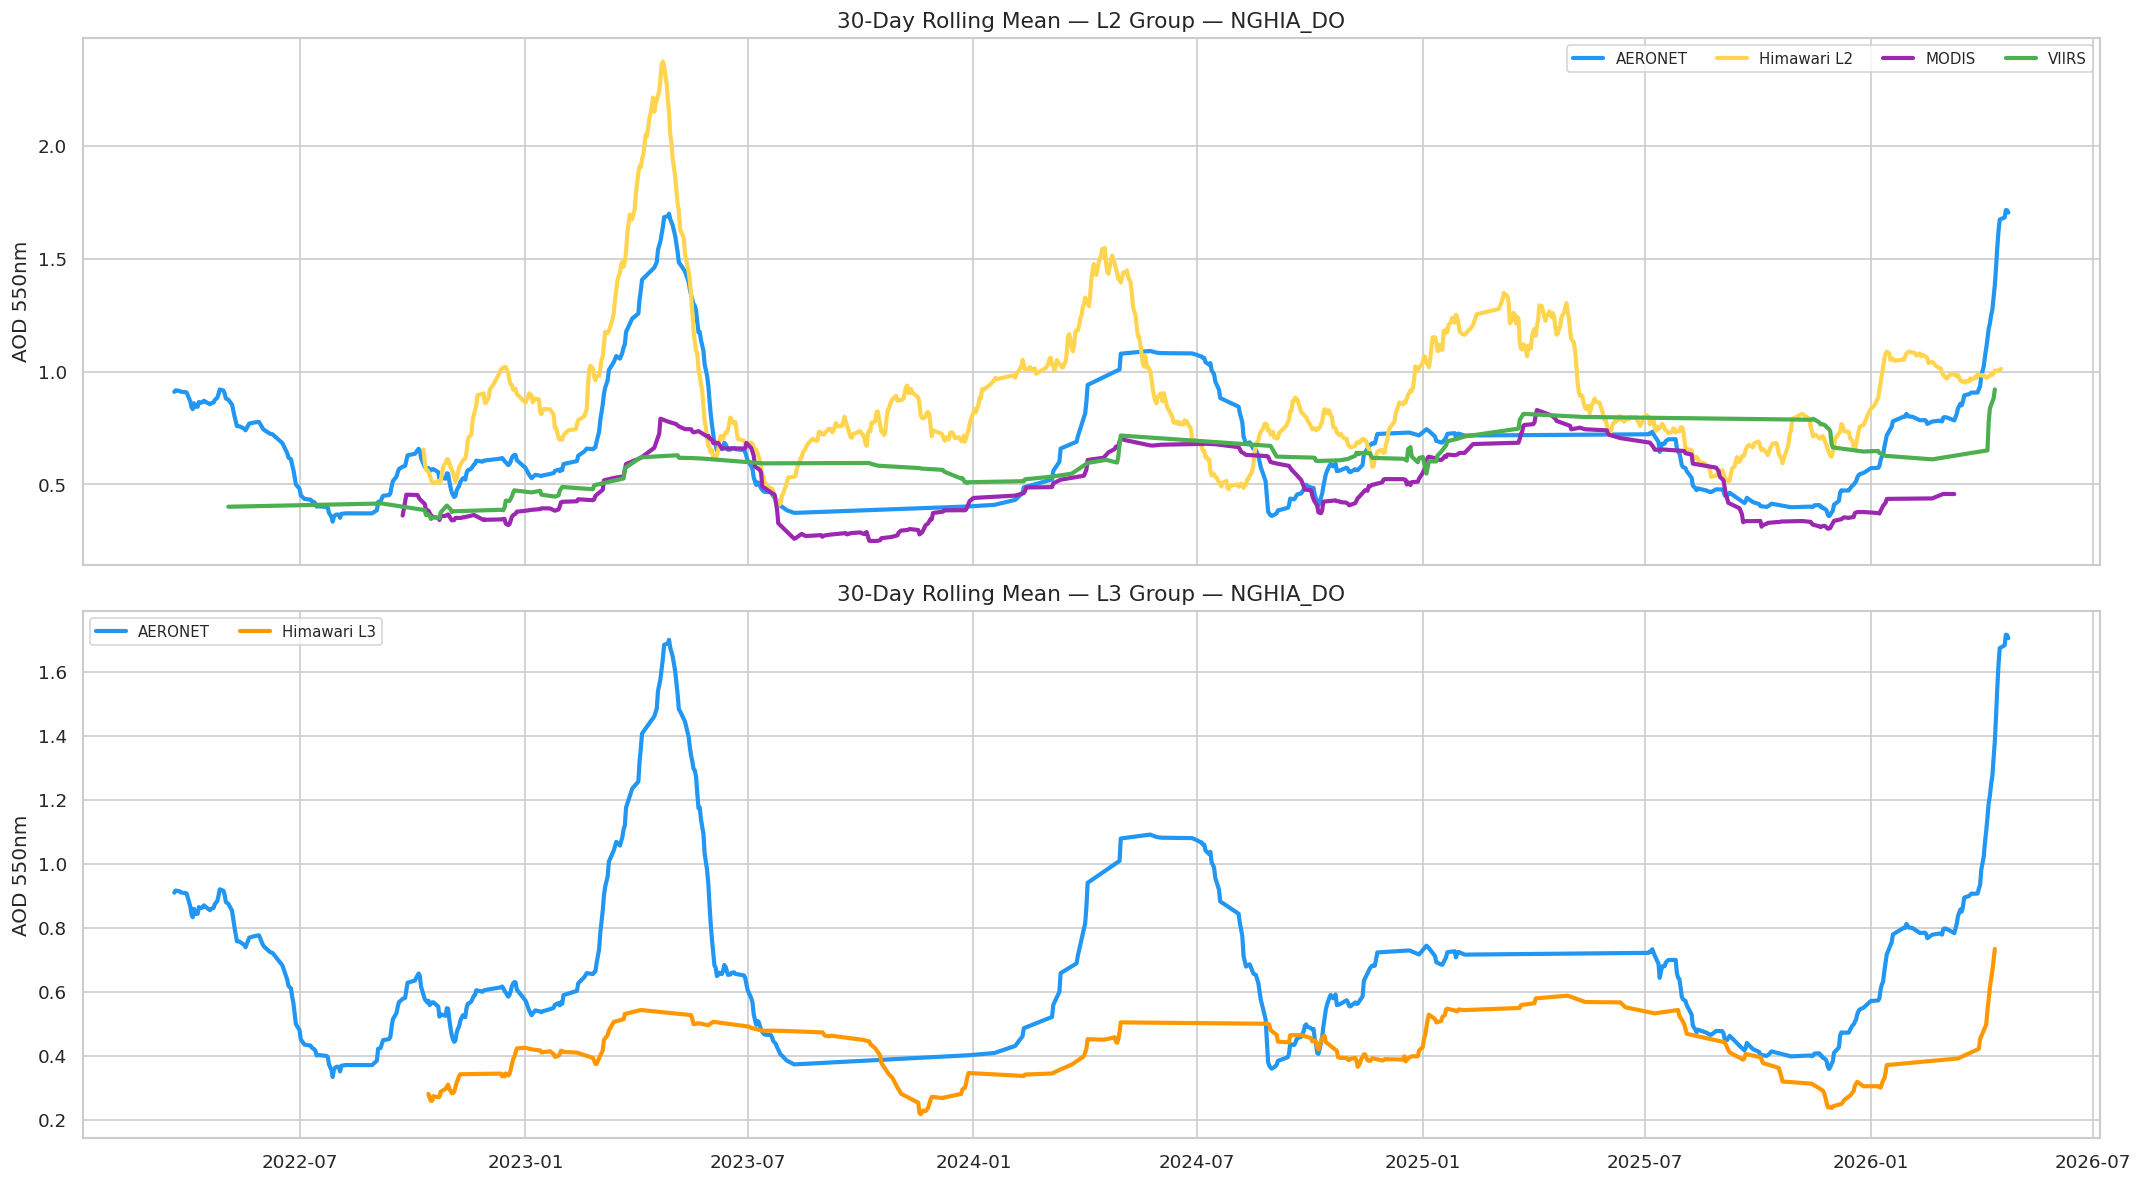

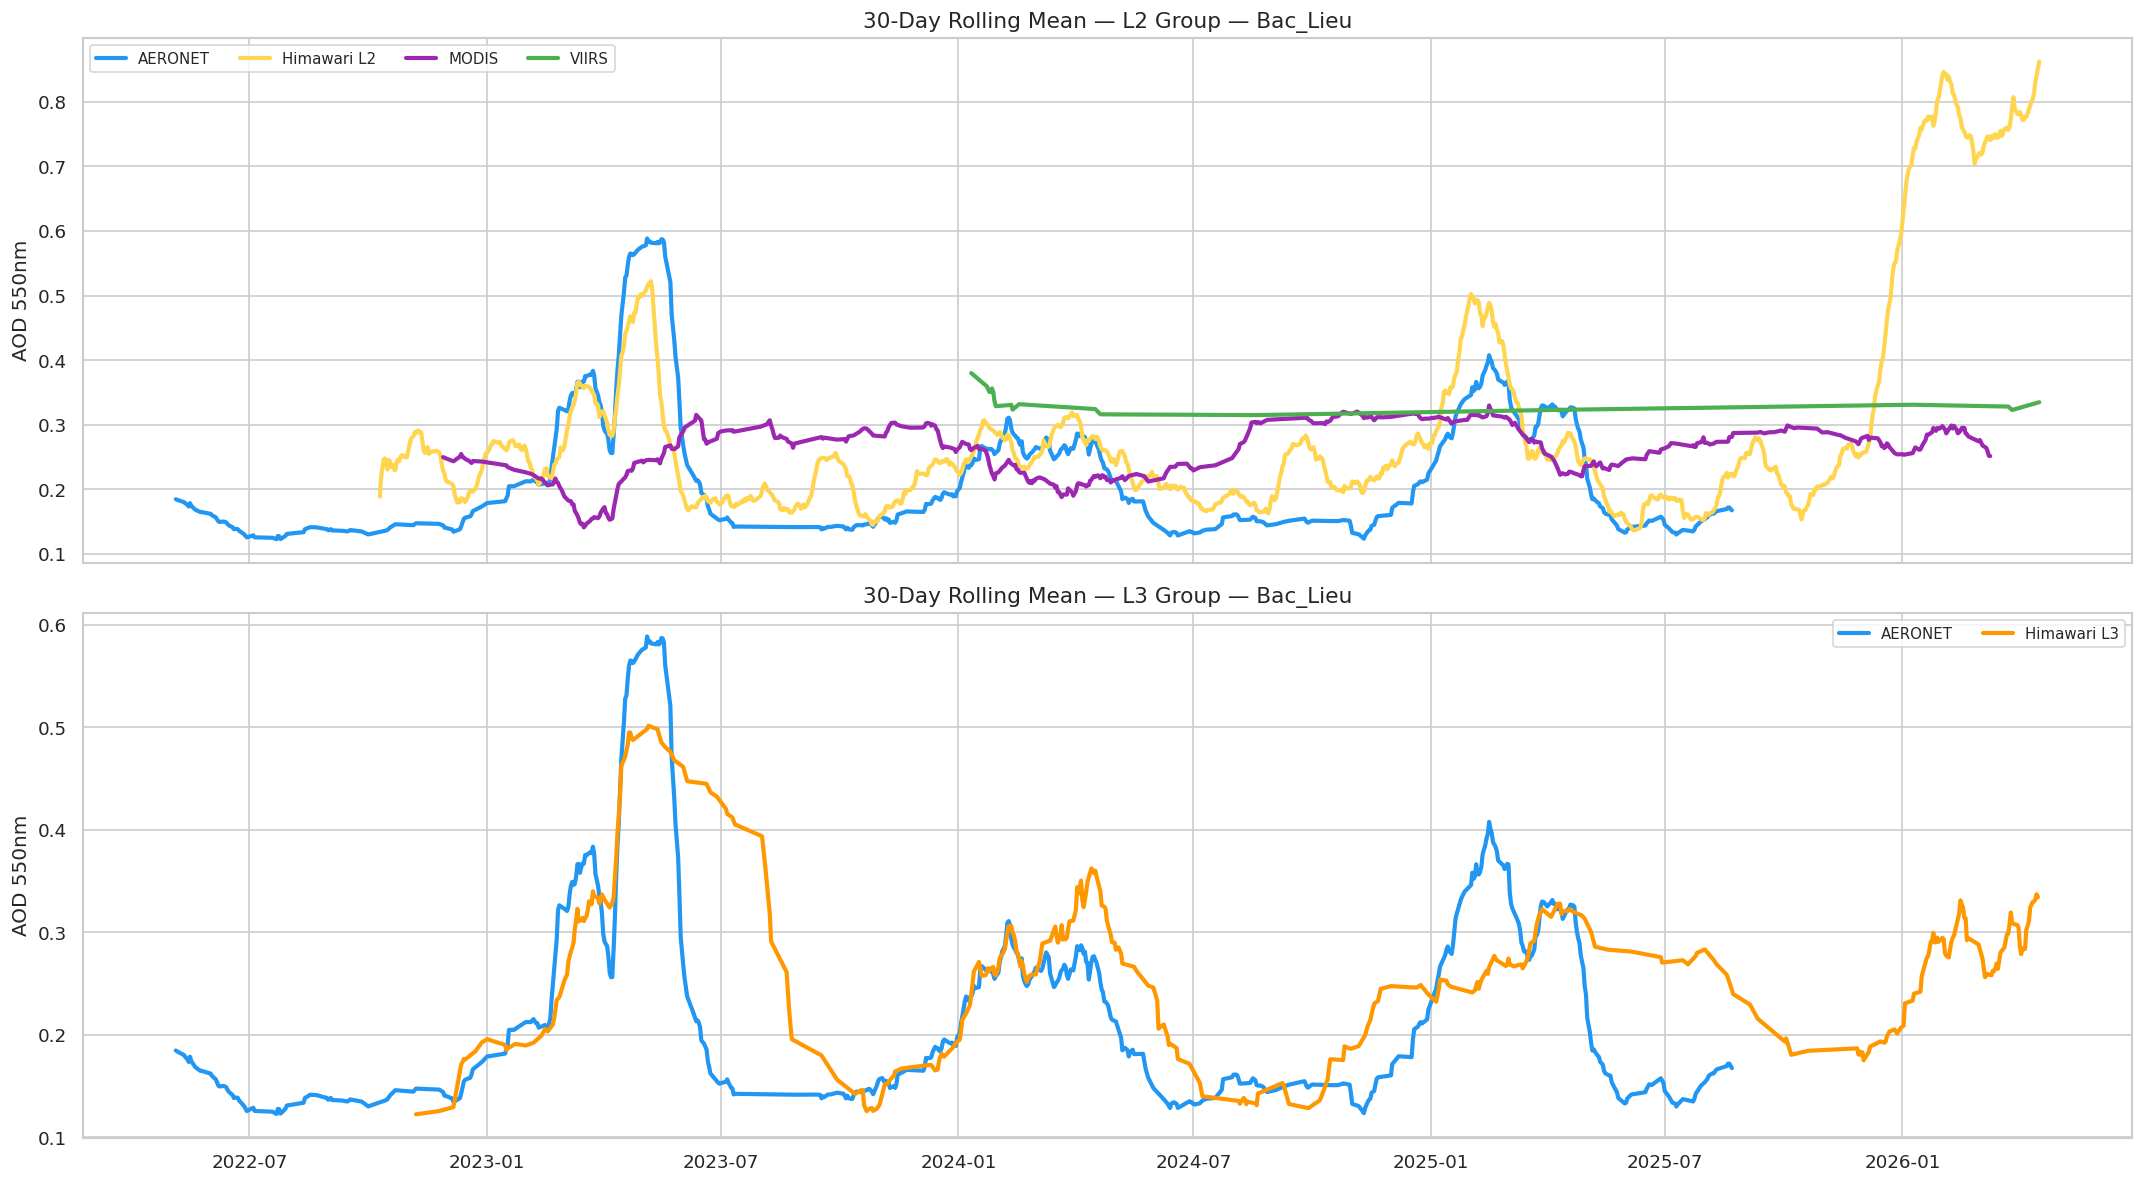

In [85]:
# ── 6.2 30-day rolling mean ──
for site in STATIONS:
    df_aer = aeronet[site]
    if df_aer.empty:
        continue

    daily_parts = {"AERONET": make_daily_series(df_aer, "AOD_550", "AERONET")}
    if not him_l2[site].empty:
        daily_parts["Himawari L2"] = make_daily_series(him_l2[site], "aod", "Himawari L2")
    if not him_l3[site].empty:
        daily_parts["Himawari L3"] = make_daily_series(him_l3[site], "aod", "Himawari L3")
    if not modis[site].empty:
        daily_parts["MODIS"] = make_daily_series(modis[site], "aod", "MODIS")
    if not viirs[site].empty:
        daily_parts["VIIRS"] = make_daily_series(viirs[site], "aod", "VIIRS")

    l2_srcs = ["AERONET", "Himawari L2", "MODIS", "VIIRS"]
    l3_srcs = ["AERONET", "Himawari L3"]

    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
    for src in l2_srcs:
        if src in daily_parts:
            s = daily_parts[src].set_index("date")["aod"].sort_index()
            r = s.rolling(30, min_periods=10).mean()
            axes[0].plot(r.index, r.values, lw=2.5,
                         color=COLORS.get(src.replace(" ", "_"), "gray"), label=src)
    axes[0].set_title(f"30-Day Rolling Mean — L2 Group — {site}")
    axes[0].set_ylabel("AOD 550nm")
    axes[0].legend(ncol=4, fontsize=9)

    for src in l3_srcs:
        if src in daily_parts:
            s = daily_parts[src].set_index("date")["aod"].sort_index()
            r = s.rolling(30, min_periods=10).mean()
            axes[1].plot(r.index, r.values, lw=2.5,
                         color=COLORS.get(src.replace(" ", "_"), "gray"), label=src)
    axes[1].set_title(f"30-Day Rolling Mean — L3 Group — {site}")
    axes[1].set_ylabel("AOD 550nm")
    axes[1].legend(ncol=2, fontsize=9)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.tight_layout()
    plt.show()

## 7. Seasonal Analysis

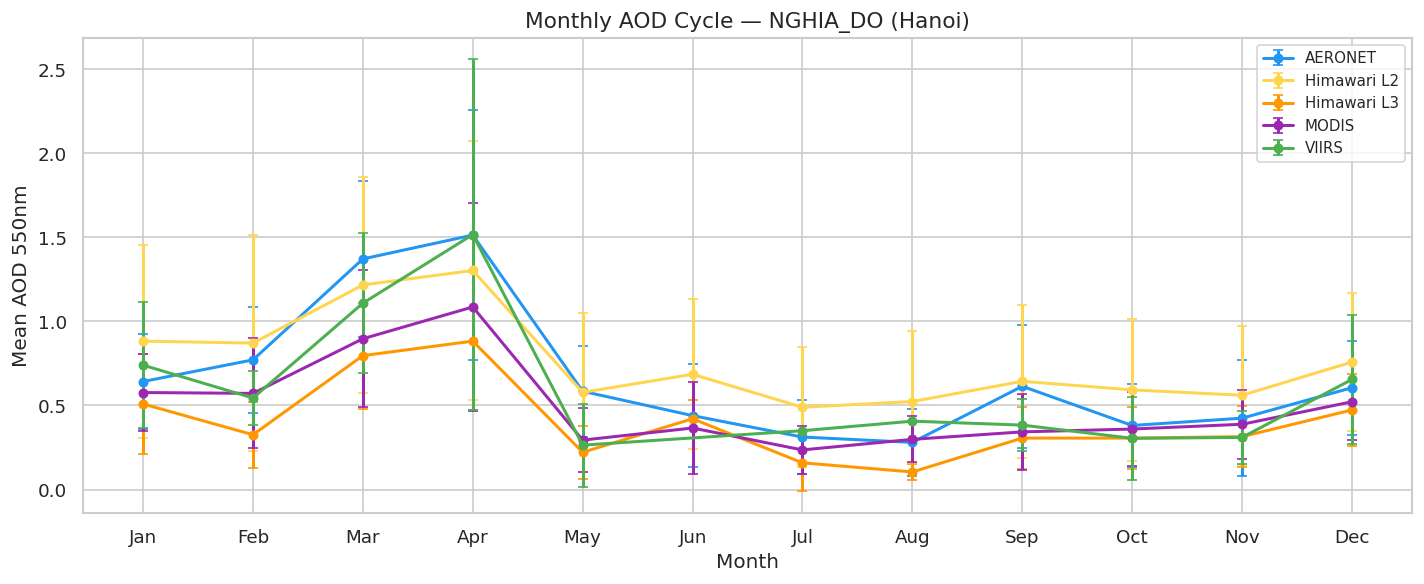

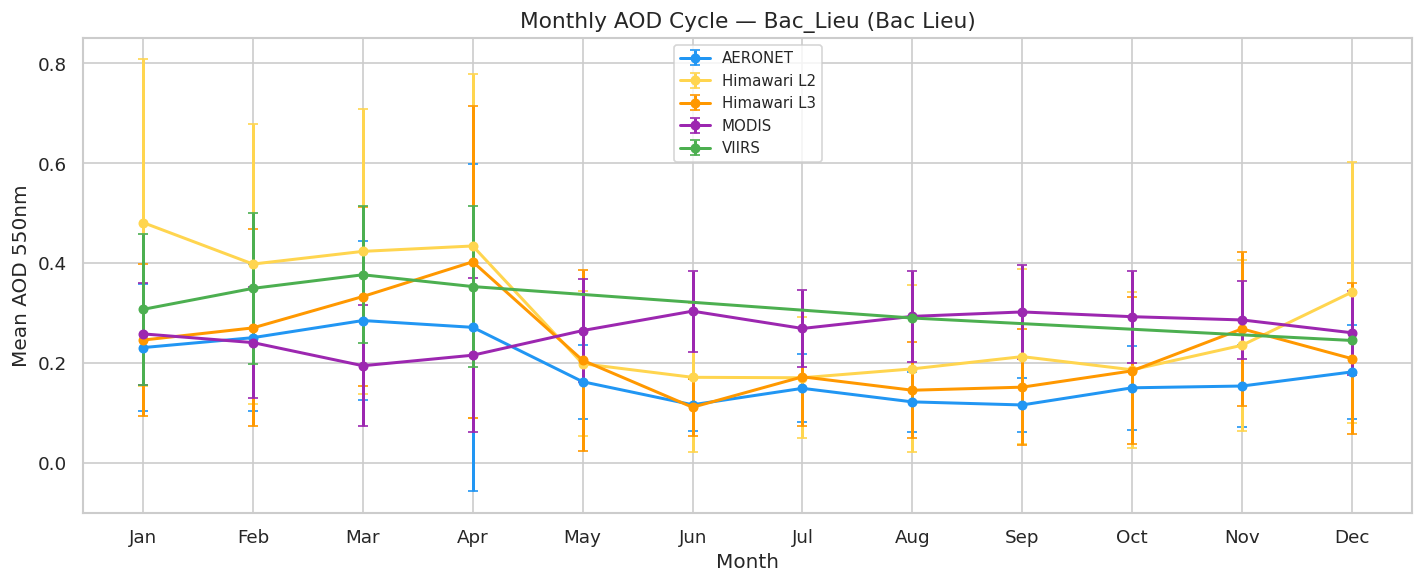

In [86]:
# ── 7.1 Monthly mean AOD cycle ──
SEASONS = {1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",
           6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON",12:"DJF"}

for site in STATIONS:
    df_aer = aeronet[site]
    if df_aer.empty:
        continue

    all_srcs = [
        ("AERONET",     df_aer,        "AOD_550"),
        ("Himawari L2", him_l2[site],  "aod"),
        ("Himawari L3", him_l3[site],  "aod"),
        ("MODIS",       modis[site],   "aod"),
        ("VIIRS",       viirs[site],   "aod"),
    ]

    fig, ax = plt.subplots(figsize=(12, 5))
    for src_name, df, col in all_srcs:
        if df.empty:
            continue
        d = df.dropna(subset=[col]).copy()
        d["month"] = pd.to_datetime(d["datetime"]).dt.month
        monthly = d.groupby("month")[col].agg(["mean", "std"]).reset_index()
        ax.errorbar(monthly["month"], monthly["mean"], yerr=monthly["std"],
                    fmt="o-", color=COLORS.get(src_name.replace(" ", "_"), "gray"),
                    label=src_name, capsize=3, lw=1.8, ms=5)

    ax.set(xlabel="Month", ylabel="Mean AOD 550nm",
           title=f"Monthly AOD Cycle — {site} ({STATIONS[site]['city']})",
           xticks=range(1, 13),
           xticklabels=["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

Seasonal Validation Metrics:
 Station      Source Season    N     R    R²  RMSE   MAE   Bias    %EE
NGHIA_DO Himawari L2    DJF 2234 0.416 0.173 0.423 0.332  0.022 30.931
NGHIA_DO Himawari L2    MAM 2589 0.638 0.407 0.773 0.612 -0.476 18.888
NGHIA_DO Himawari L2    JJA 1779 0.642 0.412 0.272 0.197  0.005 33.727
NGHIA_DO Himawari L2    SON 3154 0.763 0.582 0.242 0.160  0.012 50.190
NGHIA_DO       MODIS    DJF   78 0.764 0.584 0.226 0.152 -0.139 61.538
NGHIA_DO       MODIS    MAM   37 0.901 0.811 0.588 0.470 -0.470 18.919
NGHIA_DO       MODIS    JJA   33 0.152 0.023 0.189 0.129 -0.024 51.515
NGHIA_DO       MODIS    SON   91 0.796 0.634 0.178 0.110 -0.065 70.330
NGHIA_DO       VIIRS    DJF   39 0.666 0.444 0.240 0.151  0.034 64.103
NGHIA_DO       VIIRS    MAM   26 0.914 0.836 0.435 0.290  0.056 57.692
NGHIA_DO       VIIRS    SON   36 0.875 0.765 0.099 0.084 -0.020 72.222
NGHIA_DO Himawari L3    DJF   62 0.692 0.479 0.328 0.262 -0.255 22.581
NGHIA_DO Himawari L3    MAM   33 0.856 0.733 0.7

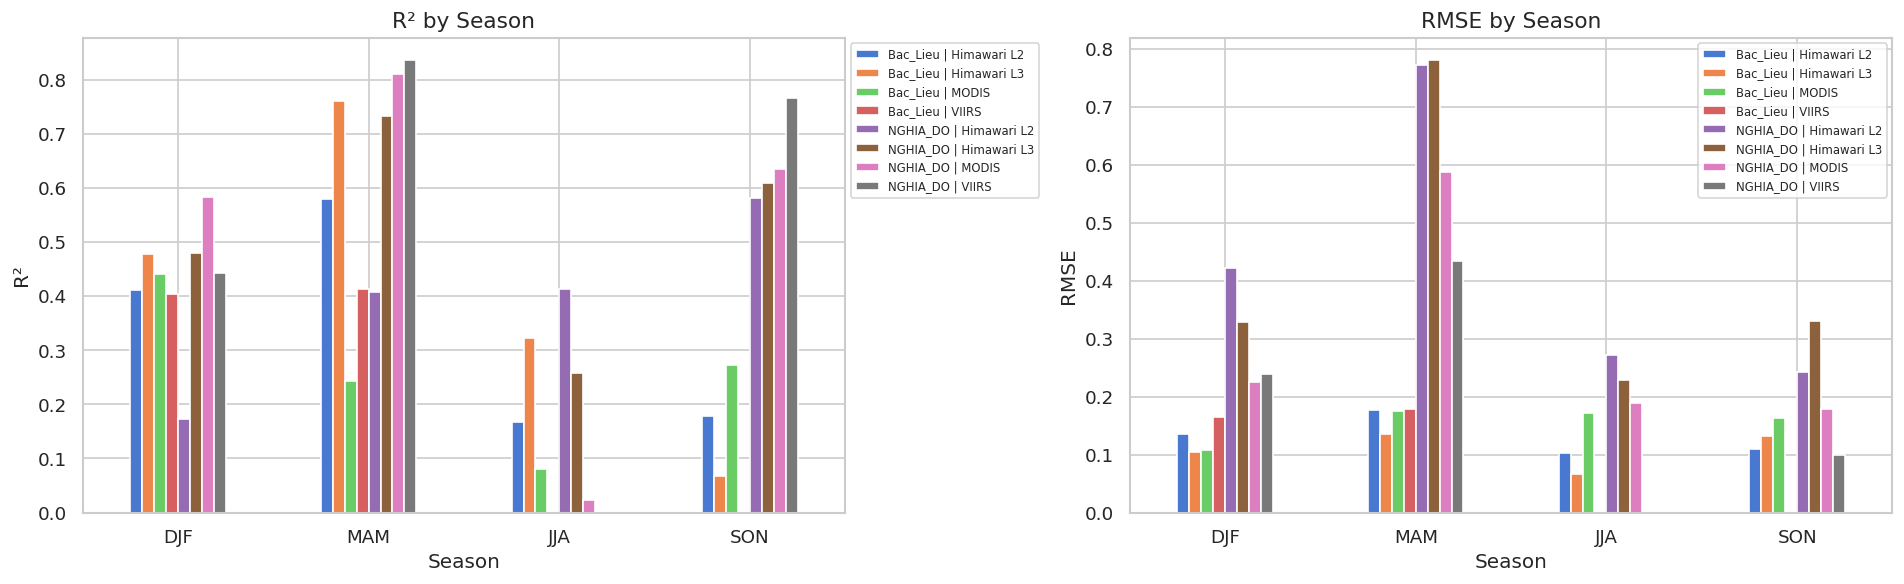

In [87]:
# ── 7.2 Seasonal validation metrics (L2 sources) ──
seasonal_rows = []

for site in STATIONS:
    if site not in matched:
        continue
    for src, df_m in matched[site].items():
        if len(df_m) < 10:
            continue
        df_m = df_m.copy()
        df_m["month"] = pd.to_datetime(df_m["datetime"]).dt.month
        df_m["season"] = df_m["month"].map(SEASONS)
        for season in ["DJF", "MAM", "JJA", "SON"]:
            sub = df_m[df_m["season"] == season]
            if len(sub) >= 3:
                m = compute_metrics(sub["aer_aod"].values, sub["sat_aod"].values)
                m.update({"Station": site, "Source": src, "Season": season})
                seasonal_rows.append(m)

if seasonal_rows:
    df_sea = pd.DataFrame(seasonal_rows)
    cols_show = ["Station", "Source", "Season", "N", "R", "R²", "RMSE", "MAE", "Bias", "%EE"]
    print("Seasonal Validation Metrics:")
    print(df_sea[[c for c in cols_show if c in df_sea.columns]].round(3).to_string(index=False))

    # R² and RMSE bar charts
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for metric, ax, title in [("R²", axes[0], "R² by Season"), ("RMSE", axes[1], "RMSE by Season")]:
        if metric not in df_sea.columns:
            continue
        df_sea["label"] = df_sea["Station"] + " | " + df_sea["Source"]
        pivot = df_sea.pivot_table(index="Season", columns="label", values=metric)
        pivot = pivot.reindex(["DJF", "MAM", "JJA", "SON"])
        pivot.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(title)
        ax.set_ylabel(metric)
        ax.legend(fontsize=7, bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()
else:
    print("Not enough seasonal data.")

## 8. Inter-Source Correlation (Daily)


Co-located daily pairs — NGHIA_DO:
  AERONET vs Himawari L2: 429 days
  AERONET vs Himawari L3: 182 days
  AERONET vs MODIS: 214 days
  AERONET vs VIIRS: 100 days
  Himawari L2 vs Himawari L3: 258 days
  Himawari L2 vs MODIS: 331 days
  Himawari L2 vs VIIRS: 128 days
  Himawari L3 vs MODIS: 210 days
  Himawari L3 vs VIIRS: 117 days
  MODIS vs VIIRS: 114 days

Co-located daily pairs — Bac_Lieu:
  AERONET vs Himawari L2: 540 days
  AERONET vs Himawari L3: 295 days
  AERONET vs MODIS: 367 days
  AERONET vs VIIRS: 23 days
  Himawari L2 vs Himawari L3: 425 days
  Himawari L2 vs MODIS: 511 days
  Himawari L2 vs VIIRS: 28 days
  Himawari L3 vs MODIS: 298 days
  Himawari L3 vs VIIRS: 26 days
  MODIS vs VIIRS: 24 days


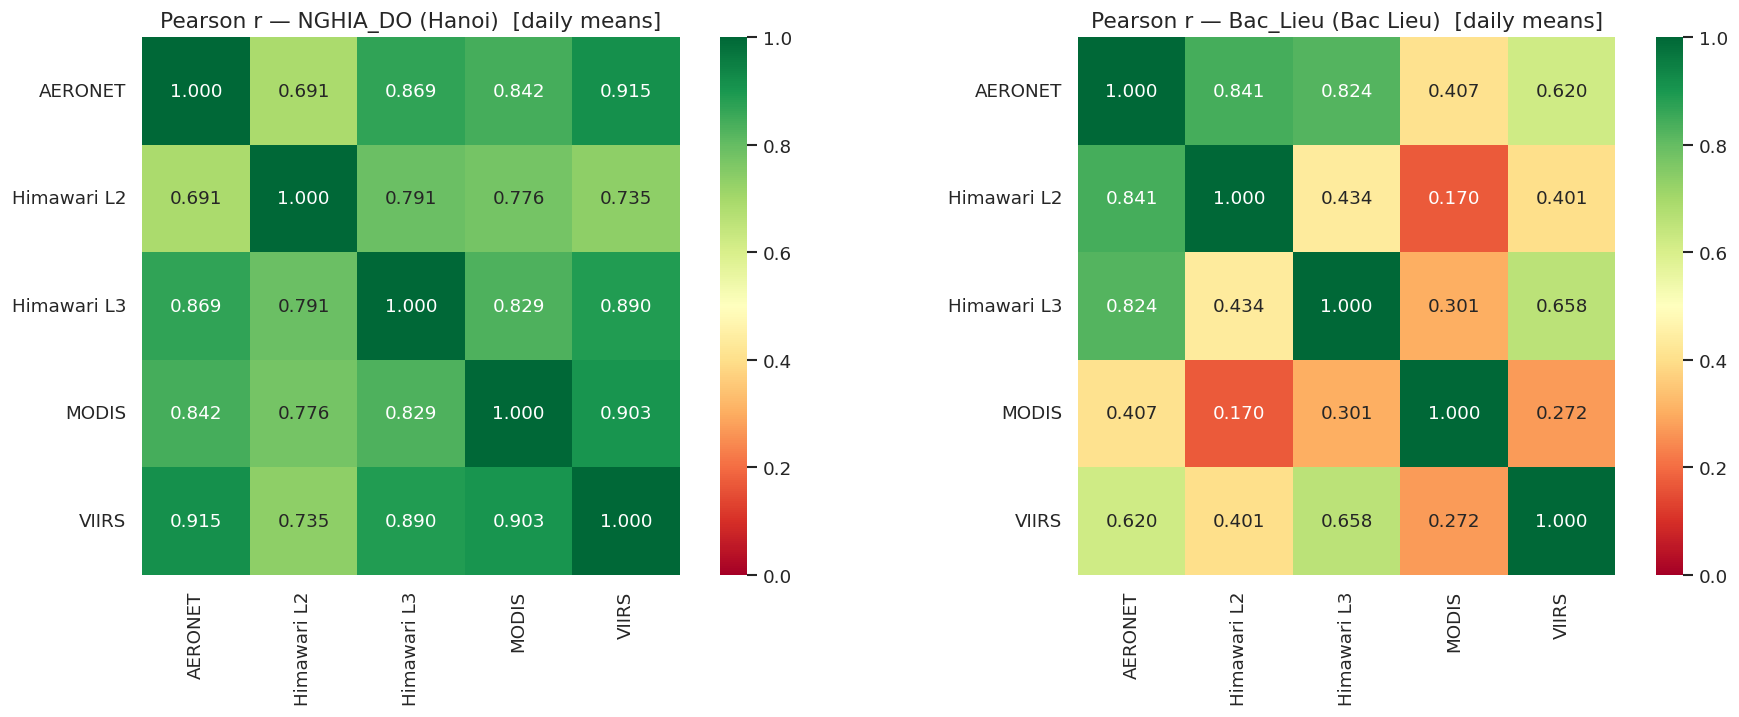

In [88]:
# ── 8.1 Pearson correlation heatmap (daily means, per station) ──
src_labels = {
    "AERONET":    (aeronet,  "AOD_550"),
    "Himawari L2":(him_l2,   "aod"),
    "Himawari L3":(him_l3,   "aod"),
    "MODIS":      (modis,    "aod"),
    "VIIRS":      (viirs,    "aod"),
}

ncols = len(STATIONS)
fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 6))
axes = np.atleast_1d(axes)

for ax, site in zip(axes, STATIONS):
    daily_map = {}
    for src_name, (data_dict, col) in src_labels.items():
        df = data_dict[site]
        if df.empty:
            continue
        s = (df.dropna(subset=[col])
             .assign(date_dt=lambda x: pd.to_datetime(x["date"]))
             .groupby("date_dt")[col]
             .mean())
        daily_map[src_name] = s

    if len(daily_map) < 2:
        ax.text(0.5, 0.5, "Not enough sources", ha="center", transform=ax.transAxes)
        ax.set_title(site)
        continue

    wide = pd.DataFrame(daily_map)
    corr = wide.corr("pearson")
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0, vmax=1, square=True, ax=ax)
    ax.set_title(f"Pearson r — {site} ({STATIONS[site]['city']})  [daily means]")

    print(f"\nCo-located daily pairs — {site}:")
    srcs = list(daily_map.keys())
    for i, s1 in enumerate(srcs):
        for s2 in srcs[i+1:]:
            n = wide[[s1, s2]].dropna().shape[0]
            print(f"  {s1} vs {s2}: {n} days")

plt.tight_layout()
plt.show()

## 9. Combined Metrics Summary

In [89]:
# ── 9.1 Full metrics table ──
rows = []
for site in STATIONS:
    if site not in matched:
        continue
    for src, df_m in matched[site].items():
        if len(df_m) < 3:
            continue
        m = compute_metrics(df_m["aer_aod"].values, df_m["sat_aod"].values)
        level = "L3/Daily" if src == "Himawari L3" else "L2 ±30min"
        rows.append({"Station": site, "City": STATIONS[site]["city"],
                     "Source": src, "Level": level, **m})

if rows:
    df_summary = pd.DataFrame(rows)
    cols = ["Station", "City", "Source", "Level", "N", "R", "R²", "RMSE", "MAE", "Bias", "Slope", "Intercept", "%EE"]
    display_cols = [c for c in cols if c in df_summary.columns]
    print("=" * 100)
    print("COMBINED VALIDATION METRICS — Satellite vs AERONET")
    print("=" * 100)
    print(df_summary[display_cols].round(4).to_string(index=False))
    print()
    print("EE = Expected Error envelope: ±(0.05 + 0.15 × AOD_AERONET)")
    print(f"L2 time matching: ±{TIME_WINDOW_MIN} min  |  L3 matching: daily mean")
else:
    print("No metrics computed — check data availability.")

COMBINED VALIDATION METRICS — Satellite vs AERONET
 Station     City      Source     Level     N      R     R²   RMSE    MAE    Bias  Slope  Intercept     %EE
NGHIA_DO    Hanoi Himawari L2 L2 ±30min  9756 0.7010 0.4915 0.4814 0.3262 -0.1166 0.5871     0.2083 34.4711
NGHIA_DO    Hanoi       MODIS L2 ±30min   239 0.8560 0.7328 0.2952 0.1822 -0.1463 0.6145     0.0847 56.9038
NGHIA_DO    Hanoi       VIIRS L2 ±30min   103 0.9150 0.8373 0.2712 0.1629  0.0219 1.1150    -0.0529 65.0485
NGHIA_DO    Hanoi Himawari L3  L3/Daily   178 0.8678 0.7531 0.4451 0.3239 -0.3159 0.5031     0.0682 24.7191
Bac_Lieu Bac Lieu Himawari L2 L2 ±30min 14092 0.7331 0.5374 0.1498 0.1030 -0.0212 0.6754     0.0593 53.6120
Bac_Lieu Bac Lieu       MODIS L2 ±30min   413 0.4111 0.1690 0.1553 0.1198  0.0129 0.3161     0.1671 42.3729
Bac_Lieu Bac Lieu       VIIRS L2 ±30min    23 0.6440 0.4147 0.1724 0.1409  0.1391 0.8029     0.1761 30.4348
Bac_Lieu Bac Lieu Himawari L3  L3/Daily   289 0.8280 0.6856 0.1189 0.0810  0.0060 0.8

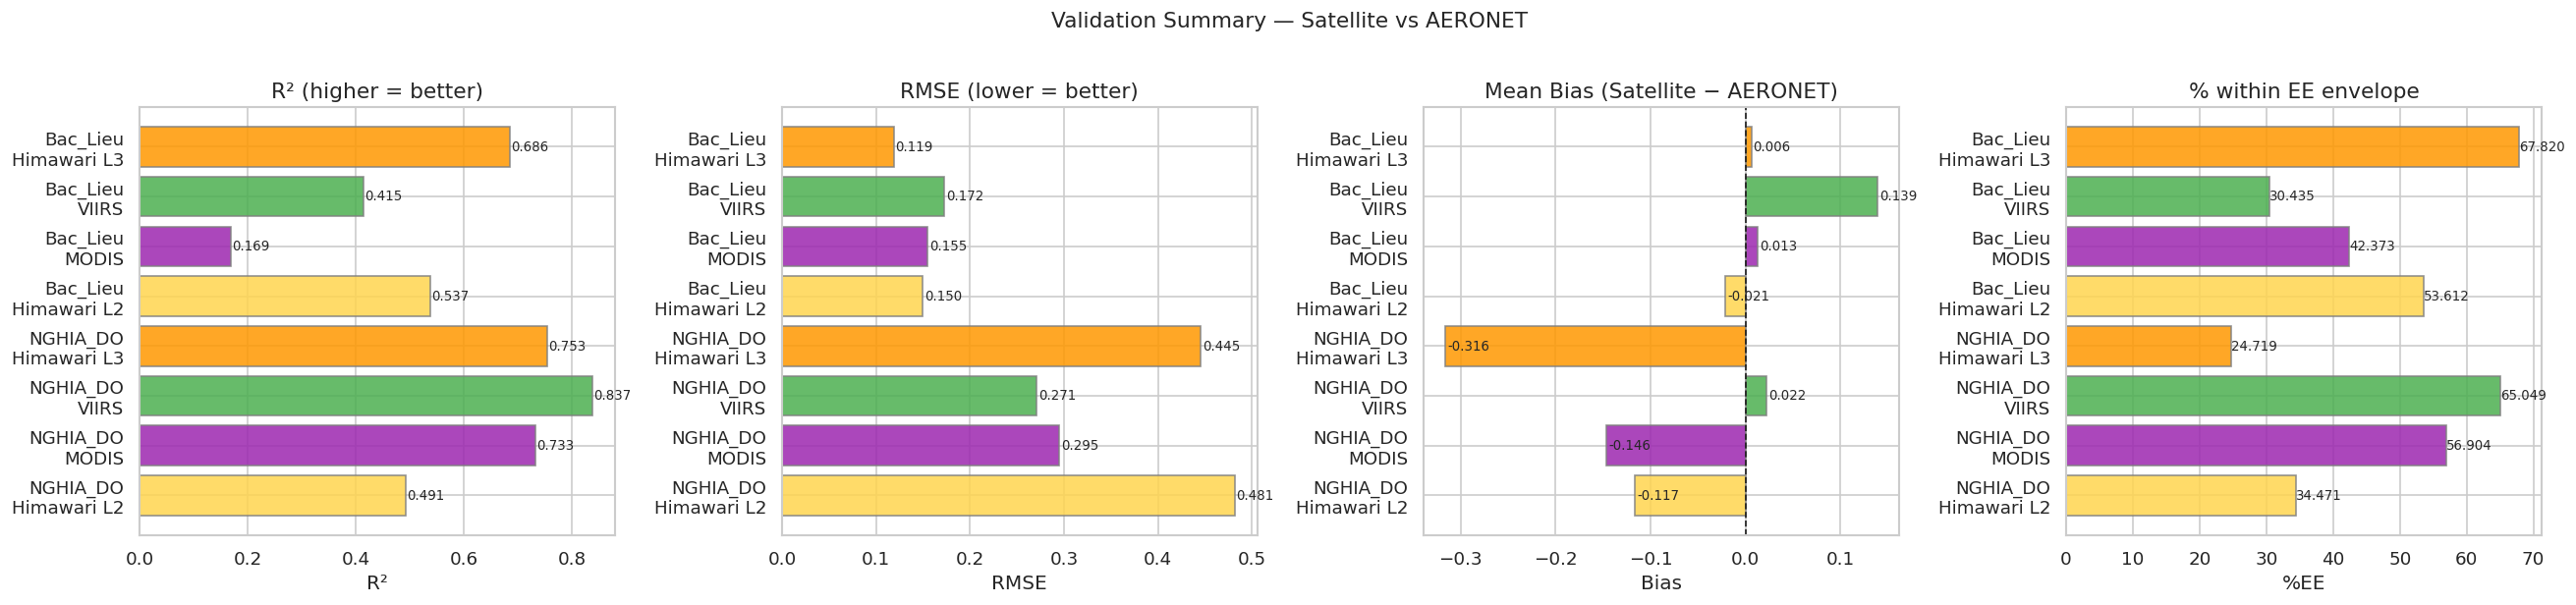

In [90]:
# ── 9.2 Bar chart summary ──
if rows:
    df_m = pd.DataFrame(rows)
    df_m["label"] = df_m["Station"] + "\n" + df_m["Source"]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    metrics_cfg = [
        ("R²",   axes[0], "R² (higher = better)"),
        ("RMSE", axes[1], "RMSE (lower = better)"),
        ("Bias", axes[2], "Mean Bias (Satellite − AERONET)"),
        ("%EE",  axes[3], "% within EE envelope"),
    ]
    for metric, ax, title in metrics_cfg:
        if metric not in df_m.columns:
            continue
        palette = [COLORS.get(r["Source"].replace(" ", "_"), "gray") for _, r in df_m.iterrows()]
        bars = ax.barh(df_m["label"], df_m[metric], color=palette, edgecolor="gray", alpha=0.85)
        ax.set_title(title)
        ax.set_xlabel(metric)
        if metric == "Bias":
            ax.axvline(0, color="k", ls="--", lw=1)
        for bar, val in zip(bars, df_m[metric]):
            ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=8)

    plt.suptitle("Validation Summary — Satellite vs AERONET", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

## 10. VIIRS Extraction Method Comparison: nearest_pixel vs radius_avg

Sensitivity analysis comparing the two VIIRS spatial extraction strategies against AERONET.

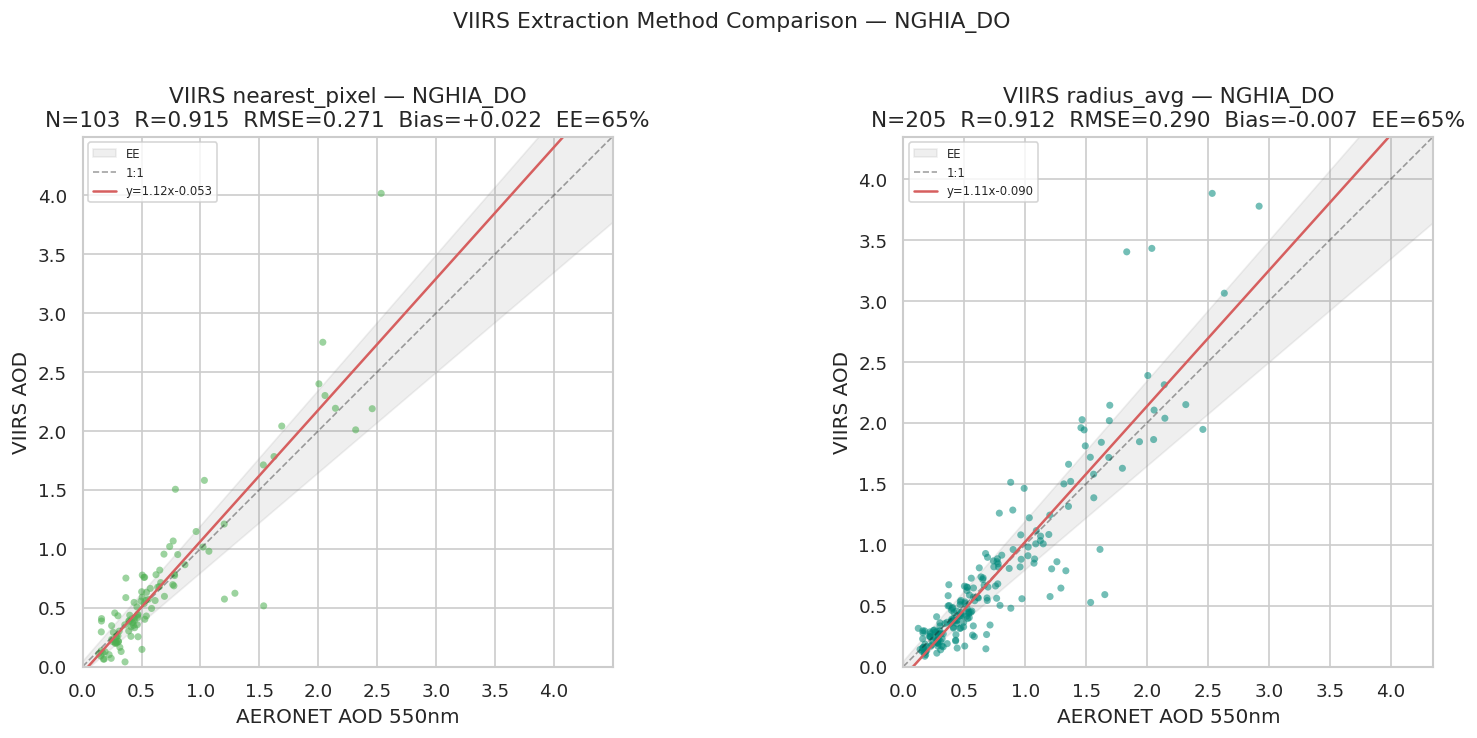

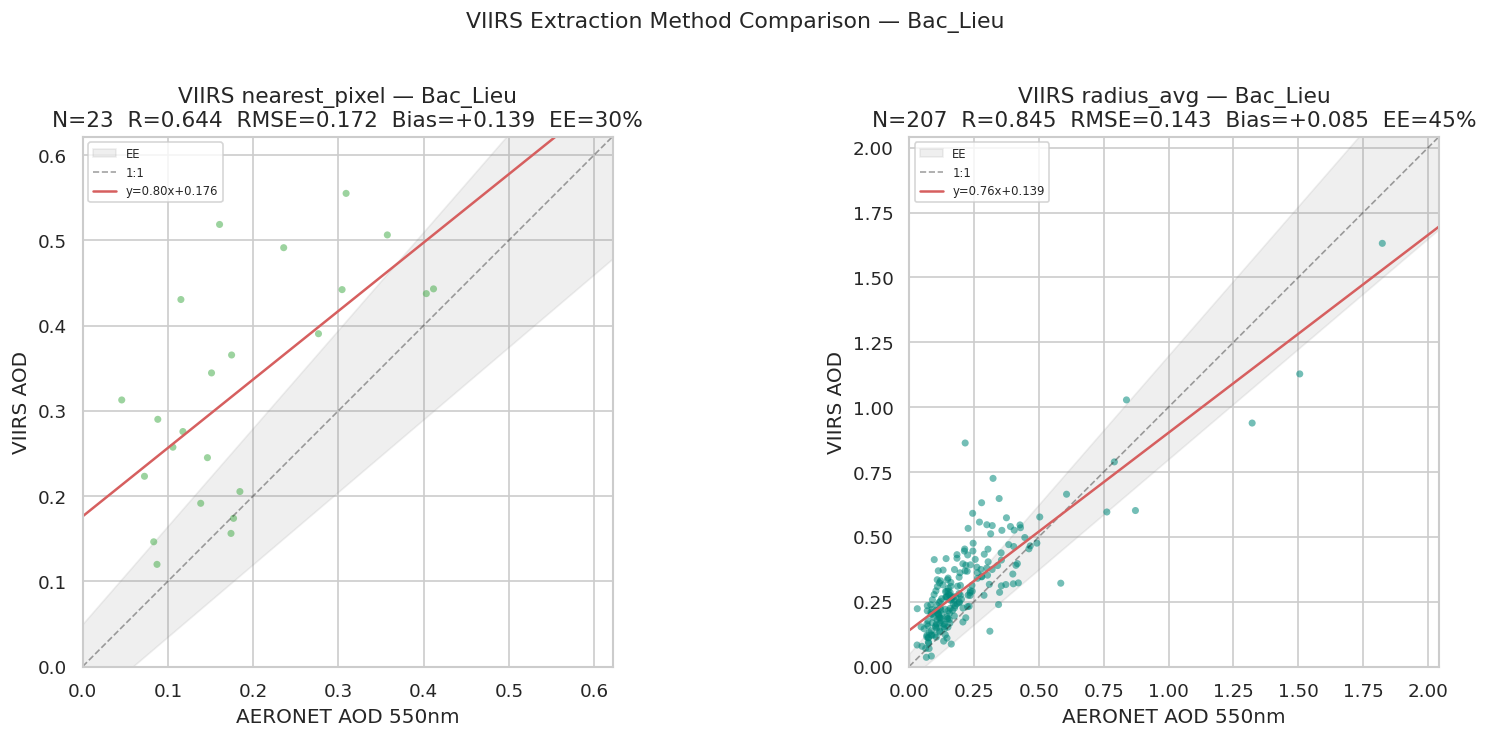


VIIRS Method Comparison Metrics:
 Station        Method   N      R     R²   RMSE    MAE    Bias     %EE
NGHIA_DO nearest_pixel 103 0.9150 0.8373 0.2712 0.1629  0.0219 65.0485
NGHIA_DO    radius_avg 205 0.9118 0.8313 0.2902 0.1731 -0.0072 64.8780
Bac_Lieu nearest_pixel  23 0.6440 0.4147 0.1724 0.1409  0.1391 30.4348
Bac_Lieu    radius_avg 207 0.8447 0.7136 0.1434 0.1114  0.0851 45.4106


In [91]:
# ── 10.1 Compare nearest_pixel vs radius_avg for each station ──
viirs_comparison_rows = []

for site in STATIONS:
    df_aer = aeronet[site]
    if df_aer.empty:
        continue

    methods = {
        "nearest_pixel": viirs_nearest[site],
        "radius_avg":    viirs_radius[site],
    }

    pairs_by_method = {}
    for method_name, df_v in methods.items():
        if df_v.empty:
            continue
        m = match_l2_to_aeronet(df_v, df_aer)
        if len(m) >= 3:
            pairs_by_method[method_name] = m
            metrics = compute_metrics(m["aer_aod"].values, m["sat_aod"].values)
            metrics.update({"Station": site, "Method": method_name})
            viirs_comparison_rows.append(metrics)

    if len(pairs_by_method) < 1:
        print(f"{site}: not enough data for comparison")
        continue

    ncols = len(pairs_by_method)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
    axes = np.atleast_1d(axes)
    method_colors = {"nearest_pixel": COLORS["VIIRS_nearest"], "radius_avg": COLORS["VIIRS_radius"]}

    for ax, (method_name, df_m) in zip(axes, pairs_by_method.items()):
        x = df_m["aer_aod"].values
        y = df_m["sat_aod"].values
        m = compute_metrics(x, y)
        lim = max(x.max(), y.max()) * 1.12
        xl = np.linspace(0, lim, 100)

        ax.fill_between(xl, xl - 0.05 - 0.15*xl, xl + 0.05 + 0.15*xl,
                        alpha=0.12, color="gray", label="EE")
        ax.plot(xl, xl, "k--", lw=1, alpha=0.4, label="1:1")
        ax.scatter(x, y, s=18, alpha=0.55, color=method_colors.get(method_name, "gray"),
                   edgecolors="none")
        ax.plot(xl, m["Slope"]*xl + m["Intercept"], "r-", lw=1.5,
                label=f"y={m['Slope']:.2f}x{m['Intercept']:+.3f}")
        ax.set(xlabel="AERONET AOD 550nm", ylabel="VIIRS AOD",
               xlim=(0, lim), ylim=(0, lim), aspect="equal")
        ax.set_title(
            f"VIIRS {method_name} — {site}\n"
            f"N={m['N']}  R={m['R']:.3f}  RMSE={m['RMSE']:.3f}  "
            f"Bias={m['Bias']:+.3f}  EE={m['%EE']:.0f}%"
        )
        ax.legend(fontsize=7, loc="upper left")

    plt.suptitle(f"VIIRS Extraction Method Comparison — {site}", y=1.02)
    plt.tight_layout()
    plt.show()

if viirs_comparison_rows:
    df_vc = pd.DataFrame(viirs_comparison_rows)
    cols = ["Station", "Method", "N", "R", "R²", "RMSE", "MAE", "Bias", "%EE"]
    display_cols = [c for c in cols if c in df_vc.columns]
    print("\nVIIRS Method Comparison Metrics:")
    print(df_vc[display_cols].round(4).to_string(index=False))

## 11. Combined Scatter Plot — All L2 Sensors vs AERONET

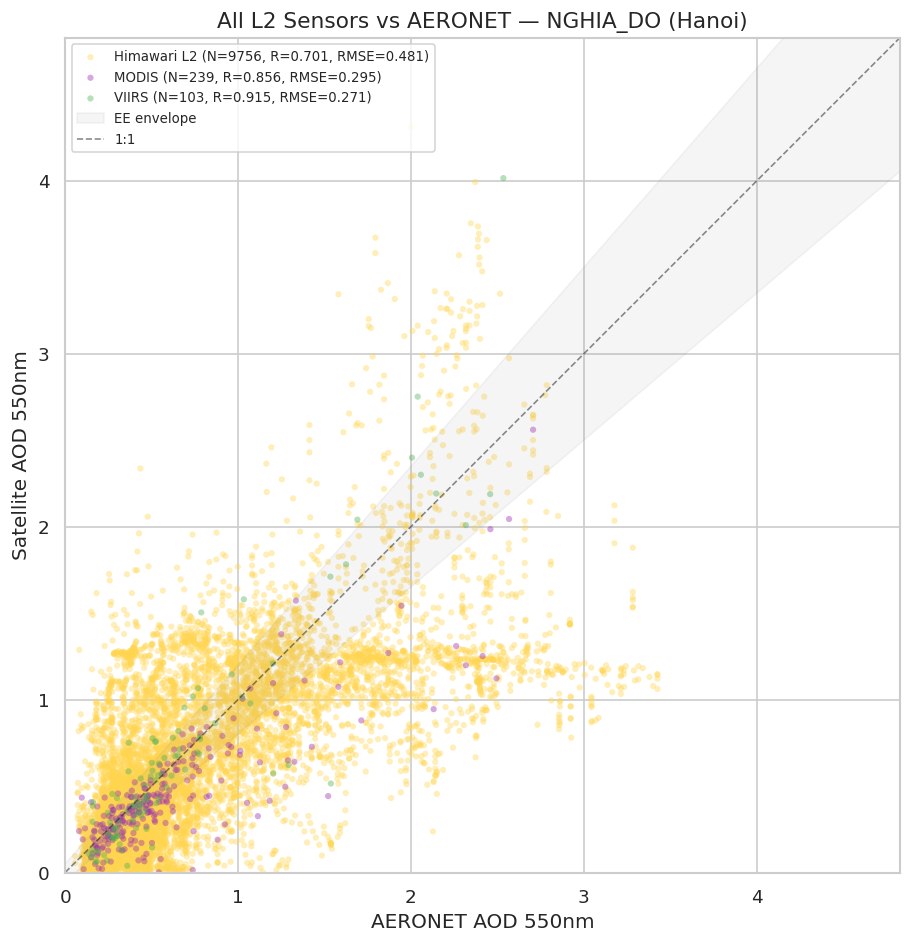

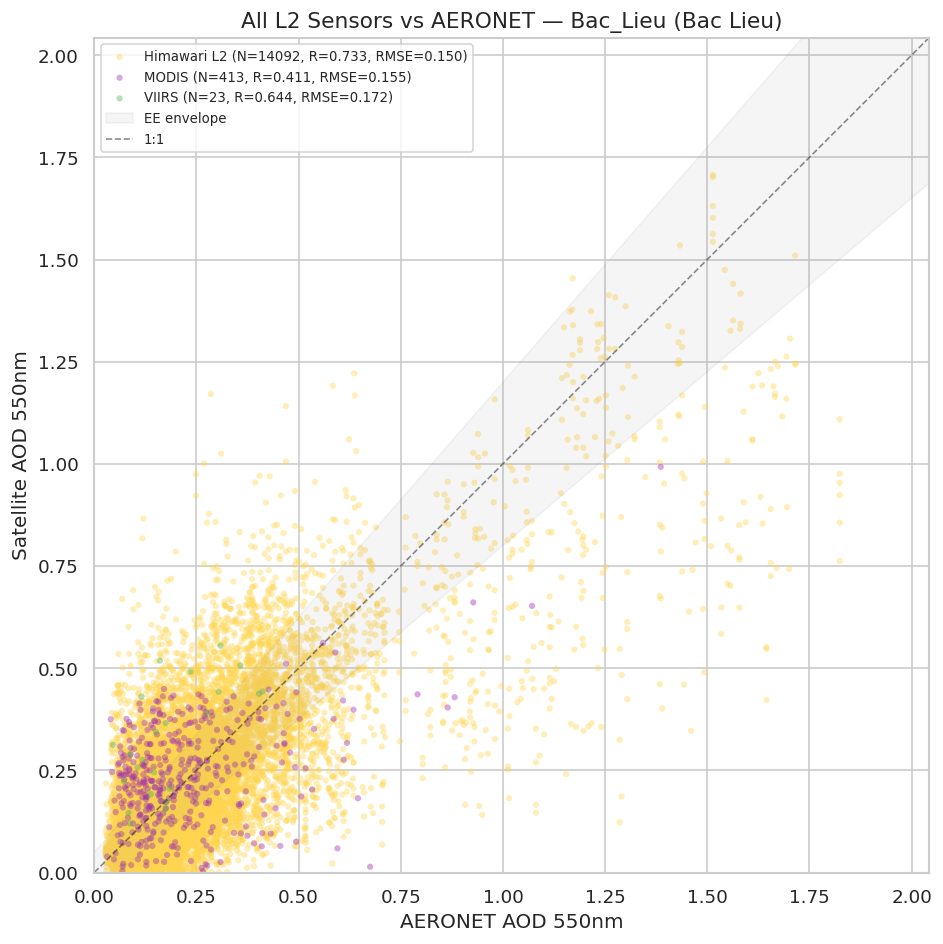

In [92]:
# ── 11.1 All L2 sensors overlaid on one scatter per station ──
l2_sources = ["Himawari L2", "MODIS", "VIIRS"]

for site in STATIONS:
    if site not in matched:
        continue
    fig, ax = plt.subplots(figsize=(8, 8))
    max_val = 0

    for src in l2_sources:
        if src not in matched[site] or len(matched[site][src]) < 3:
            continue
        df_m = matched[site][src]
        x = df_m["aer_aod"].values
        y = df_m["sat_aod"].values
        m = compute_metrics(x, y)
        max_val = max(max_val, x.max(), y.max())
        ax.scatter(x, y, s=14, alpha=0.4, edgecolors="none",
                   color=COLORS.get(src.replace(" ", "_"), "gray"),
                   label=f"{src} (N={m['N']}, R={m['R']:.3f}, RMSE={m['RMSE']:.3f})")

    lim = max_val * 1.12 if max_val > 0 else 3
    xl = np.linspace(0, lim, 100)
    ax.fill_between(xl, xl - 0.05 - 0.15*xl, xl + 0.05 + 0.15*xl,
                    alpha=0.08, color="gray", label="EE envelope")
    ax.plot(xl, xl, "k--", lw=1, alpha=0.5, label="1:1")
    ax.set(xlabel="AERONET AOD 550nm", ylabel="Satellite AOD 550nm",
           xlim=(0, lim), ylim=(0, lim), aspect="equal")
    ax.set_title(f"All L2 Sensors vs AERONET — {site} ({STATIONS[site]['city']})")
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()